# Notebook 5 - Analisis de Negocio

Este cuaderno desarrolla la fase de Analisis de Negocio a partir de la base municipal segmentada generada en el `Notebook 4`.

A diferencia de los cuadernos anteriores, aqui el objetivo principal no es construir ni validar el dato, sino traducir los resultados tecnicos a una lectura aplicada para el sector asegurador. En este contexto, se interpretan los clusters, los indicadores de peligro climatico, la vulnerabilidad territorial, la exposicion fisica derivada de Catastro y la exposicion a inundacion procedente de SNCZI con el fin de identificar perfiles municipales relevantes, prioridades de actuacion y posibles implicaciones para tarificacion, prevencion y gestion de cartera.

La segmentacion principal utilizada para negocio es la obtenida con `KMeans`. Los resultados de `Agglomerative Clustering` y `DBSCAN` se conservan como contrastes metodologicos: el primero ayuda a comprobar estabilidad y el segundo aporta una lectura auxiliar de densidad espacial y municipios singulares, pero no se utiliza como segmentacion operativa principal.

La entrada principal del notebook es:

`DATA/PROCESSED/dataset_cv_municipios_segmentado.csv`

La finalidad practica del cuaderno es convertir resultados tecnicos en hipotesis de uso asegurador: vigilancia, prevencion, segmentacion territorial y priorizacion de futuras integraciones de datos. En ningun caso se plantea como una herramienta de decision automatica, ya que faltan siniestros reales, primas, capitales asegurados y composicion efectiva de cartera.

## 0. Configuracion inicial

En este bloque se cargan las librerias necesarias y se definen las rutas de trabajo. El notebook parte de la base municipal ya enriquecida y segmentada, por lo que no repite ni el proceso ETL ni el modelado previo.

Ademas, se preparan las rutas para posibles salidas de tablas, mapas y materiales de apoyo orientados a la interpretacion de negocio.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import re
import unicodedata

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "DATA"
PROC = DATA / "PROCESSED"
EXT = DATA / "EXTERNAL"
OUT = ROOT / "output"
MAPS = OUT / "maps"
BUSINESS_OUT = OUT / "negocio"

SEGMENTED_MUNICIPAL_FILE = PROC / "dataset_cv_municipios_segmentado.csv"
MUNICIPIOS_GEO_FILE = EXT / "municipios_cv.geojson"
MODEL_OUT = OUT / "modelado"
RF_IMPORTANCE_FILE = MODEL_OUT / "rf_score_feature_importance.csv"
RF_METRICS_FILE = MODEL_OUT / "rf_score_metrics.csv"
RF_BLOCK_IMPORTANCE_FILE = MODEL_OUT / "rf_score_block_importance.csv"
RF_PREDICTIONS_FILE = MODEL_OUT / "rf_score_predictions.csv"
RF_METHODOLOGY_FILE = MODEL_OUT / "rf_score_methodology.csv"
RF_SHAP_STATUS_FILE = MODEL_OUT / "rf_score_shap_status.csv"
RF_SHAP_IMPORTANCE_FILE = MODEL_OUT / "rf_score_shap_importance.csv"
DANA_2024_FILE = PROC / "dana_2024_municipios_afectados_boe.csv"
BUSINESS_MUNICIPAL_FILE = PROC / "dataset_cv_municipios_negocio.csv"

MAPS.mkdir(parents=True, exist_ok=True)
BUSINESS_OUT.mkdir(parents=True, exist_ok=True)

print("Base municipal segmentada:", SEGMENTED_MUNICIPAL_FILE)
print("Existe:", SEGMENTED_MUNICIPAL_FILE.exists())
print("Geometria municipal disponible:", MUNICIPIOS_GEO_FILE.exists())
print("Importancia RF disponible:", RF_IMPORTANCE_FILE.exists())
print("Metricas RF disponibles:", RF_METRICS_FILE.exists())
print("Predicciones RF disponibles:", RF_PREDICTIONS_FILE.exists())
print("Estado SHAP disponible:", RF_SHAP_STATUS_FILE.exists())
print("Importancia SHAP disponible:", RF_SHAP_IMPORTANCE_FILE.exists())
print("Referencia DANA 2024 disponible:", DANA_2024_FILE.exists())
print("Directorio de salida negocio:", BUSINESS_OUT)
print("Salida municipal de negocio:", BUSINESS_MUNICIPAL_FILE)

Base municipal segmentada: C:\Users\gonza\OneDrive\tfg\DATA\PROCESSED\dataset_cv_municipios_segmentado.csv
Existe: True
Geometria municipal disponible: True
Importancia RF disponible: True
Metricas RF disponibles: True
Predicciones RF disponibles: True
Estado SHAP disponible: True
Importancia SHAP disponible: True
Referencia DANA 2024 disponible: True
Directorio de salida negocio: C:\Users\gonza\OneDrive\tfg\output\negocio
Salida municipal de negocio: C:\Users\gonza\OneDrive\tfg\DATA\PROCESSED\dataset_cv_municipios_negocio.csv


## 1. Objetivo de negocio y carga de la base segmentada

El objetivo de esta fase es interpretar la informacion municipal generada en los cuadernos anteriores desde una perspectiva aplicada al negocio asegurador. Para ello, se parte de los clusters, de los indicadores climaticos, de las variables territoriales, de la exposicion edificada y de la exposicion a inundacion ya construidas, y se analizan en terminos de peligro, vulnerabilidad, exposicion y prioridad operativa.

Dado que no se dispone de datos reales de siniestralidad, esta lectura no pretende sustituir un modelo actuarial ni una tarificacion real, sino ofrecer una aproximacion exploratoria que ayude a identificar perfiles municipales de interes, zonas de vigilancia prioritaria y posibles lineas de continuidad para una aseguradora.

`DBSCAN` aparece en esta fase como comprobacion de coherencia con el modelado anterior. Su utilidad de negocio es senalar agrupaciones densas o municipios singulares, pero las etiquetas de perfil y las prioridades operativas se construyen sobre `KMeans`, por ser la solucion mas equilibrada e interpretable.

In [2]:
df_seg = pd.read_csv(SEGMENTED_MUNICIPAL_FILE, dtype={"cod_ine": "string"})

if "cod_ine" not in df_seg.columns:
    raise ValueError("La base segmentada debe conservar cod_ine para trazabilidad municipal.")

# La provincia se deriva del codigo INE provincial, no de etiquetas NUTS,
# para evitar mapeos ambiguos o desplazados en la lectura de negocio.
df_seg["cod_ine"] = df_seg["cod_ine"].astype("string").str.zfill(5)
province_by_ine_prefix = {
    "03": "Alicante",
    "12": "Castellon",
    "46": "Valencia",
}
df_seg["provincia"] = df_seg["cod_ine"].str[:2].map(province_by_ine_prefix)
assert df_seg["cod_ine"].str.len().eq(5).all(), "cod_ine debe conservar 5 digitos."
assert df_seg["provincia"].isna().sum() == 0, "No se ha podido asignar provincia a todos los municipios."
assert set(df_seg["cod_ine"].str[:2]) == set(province_by_ine_prefix), "Prefijos provinciales INE inesperados."


riesgo_col = "score_riesgo_exploratorio"
peligro_col = "score_peligro_climatico_ampliado"
vulnerabilidad_col = "score_vulnerabilidad"
exposicion_col = "score_exposicion_fisica"
exposicion_construida_col = "score_exposicion_construida"
exposicion_inundacion_col = "score_exposicion_inundacion"
snczi_t100_col = "snczi_inundacion_t100_pct_area_aprox"
snczi_t500_col = "snczi_inundacion_t500_pct_area_aprox"
score_contribution_cols = [
    "contrib_peligro_climatico",
    "contrib_vulnerabilidad",
    "contrib_exposicion_fisica",
]
dominant_dimension_col = "dimension_dominante_score"

required_cols = [
    "municipio", "CODNUT2", "CODNUT3", "cluster_kmeans", "cluster_agg", "cluster_dbscan",
    riesgo_col, peligro_col, vulnerabilidad_col, exposicion_col,
    exposicion_construida_col, exposicion_inundacion_col, snczi_t100_col, snczi_t500_col,
    *score_contribution_cols, dominant_dimension_col,
]
missing_required = [col for col in required_cols if col not in df_seg.columns]
if missing_required:
    raise ValueError(f"Faltan columnas necesarias para el analisis de negocio: {missing_required}")

print("Shape:", df_seg.shape)
print("Municipios unicos:", df_seg["municipio"].nunique())
print("Duplicados municipales:", df_seg.duplicated(subset=["municipio", "CODNUT2", "CODNUT3"]).sum())
print("Clusters KMeans disponibles:", sorted(df_seg["cluster_kmeans"].dropna().unique().tolist()))
print("Clusters Agglomerative disponibles:", sorted(df_seg["cluster_agg"].dropna().unique().tolist()))
print("Etiquetas DBSCAN disponibles:", sorted(df_seg["cluster_dbscan"].dropna().unique().tolist()))
print("Municipios marcados como ruido por DBSCAN:", int((df_seg["cluster_dbscan"] == -1).sum()))

assert df_seg["municipio"].nunique() == 542, "La base segmentada debe conservar 542 municipios."
assert df_seg.duplicated(subset=["municipio", "CODNUT2", "CODNUT3"]).sum() == 0, "Hay duplicados municipales."
assert df_seg["cluster_kmeans"].nunique() == 4, "El analisis de negocio espera la solucion KMeans final de 4 clusters."
assert df_seg["cluster_dbscan"].isna().sum() == 0, "Hay municipios sin etiqueta DBSCAN."

business_cols = [
    "municipio",
    "cluster_kmeans",
    "cluster_dbscan",
    riesgo_col,
    peligro_col,
    vulnerabilidad_col,
    exposicion_construida_col,
    exposicion_inundacion_col,
    exposicion_col,
    snczi_t100_col,
    snczi_t500_col,
    *score_contribution_cols,
    dominant_dimension_col,
    "precip_p99",
    "dias_calor_intenso",
    "dias_suelo_seco",
    "densidad_poblacion",
    "densidad_viviendas_catastro_km2",
    "ratio_huella_edificada_pct",
    "altitud_m",
]

business_cols = [col for col in business_cols if col in df_seg.columns]
display(df_seg[business_cols].head())

Shape: (542, 120)
Municipios unicos: 542
Duplicados municipales: 0
Clusters KMeans disponibles: [0, 1, 2, 3]
Clusters Agglomerative disponibles: [0, 1, 2, 3]
Etiquetas DBSCAN disponibles: [-1, 0, 1, 2]
Municipios marcados como ruido por DBSCAN: 59


,municipio,cluster_kmeans,cluster_dbscan,score_riesgo_exploratorio,score_peligro_climatico_ampliado,score_vulnerabilidad,score_exposicion_construida,score_exposicion_inundacion,score_exposicion_fisica,snczi_inundacion_t100_pct_area_aprox,snczi_inundacion_t500_pct_area_aprox,contrib_peligro_climatico,contrib_vulnerabilidad,contrib_exposicion_fisica,dimension_dominante_score,precip_p99,dias_calor_intenso,dias_suelo_seco,densidad_poblacion,densidad_viviendas_catastro_km2,ratio_huella_edificada_pct,altitud_m
0,Ademuz,1,-1,0.244092,0.229361,0.430498,0.002188,0.000000,0.001313,0.000000,0.000000,0.114680,0.129149,0.000263,vulnerabilidad,18.368174,60,0,10.12,14.38,0.1728,907.0
1,Ador,2,0,0.366768,0.519953,0.348130,0.011108,0.012747,0.011764,0.004943,0.018251,0.259976,0.104439,0.002353,peligro climatico,37.833611,68,537,126.84,70.97,1.0499,79.0
2,Agost,3,0,0.301895,0.387744,0.355532,0.007359,0.006009,0.006819,0.004800,0.005891,0.193872,0.106660,0.001364,peligro climatico,18.520694,97,1505,78.39,43.79,0.8237,181.0
3,Agres,2,0,0.310747,0.389693,0.384731,0.004014,0.000000,0.002408,0.000000,0.000000,0.194846,0.115419,0.000482,peligro climatico,31.017301,176,0,24.10,23.64,0.4122,756.0
4,Agullent,2,0,0.312086,0.402116,0.360871,0.020919,0.003200,0.013832,0.002691,0.002990,0.201058,0.108261,0.002766,peligro climatico,28.305807,200,84,150.09,72.46,2.7882,556.0


### 1.1 Papel de cada enfoque de modelado en negocio

Antes de interpretar perfiles y prioridades, se deja fijado que papel tiene cada algoritmo en esta fase. Esto evita mezclar una segmentacion operativa con pruebas de contraste metodologico.

In [3]:
modeling_role_table = pd.DataFrame(
    [
        {
            "enfoque": "KMeans",
            "papel_en_negocio": "Segmentacion principal",
            "motivo": "Solucion equilibrada, estable e interpretable para definir perfiles municipales.",
        },
        {
            "enfoque": "Agglomerative Clustering",
            "papel_en_negocio": "Contraste metodologico",
            "motivo": "Permite comprobar si la estructura territorial se mantiene con otro algoritmo.",
        },
        {
            "enfoque": "DBSCAN",
            "papel_en_negocio": "Lectura auxiliar de densidad",
            "motivo": "Ayuda a detectar agrupaciones densas y municipios singulares, pero no sustituye a KMeans.",
        },
    ]
)

display(modeling_role_table)

dbscan_business_reading = (
    df_seg.assign(es_ruido_dbscan=df_seg["cluster_dbscan"].eq(-1))
    .groupby("cluster_dbscan")
    .agg(
        municipios=("municipio", "count"),
        riesgo_exploratorio=(riesgo_col, "mean"),
        peligro_climatico_ampliado=(peligro_col, "mean"),
        vulnerabilidad_media=(vulnerabilidad_col, "mean"),
        exposicion_fisica_media=(exposicion_col, "mean"),
        ruido_dbscan=("es_ruido_dbscan", "max"),
    )
    .round(3)
)

display(dbscan_business_reading)

,enfoque,papel_en_negocio,motivo
0,KMeans,Segmentacion principal,"Solucion equilibrada, estable e interpretable ..."
1,Agglomerative Clustering,Contraste metodologico,Permite comprobar si la estructura territorial...
2,DBSCAN,Lectura auxiliar de densidad,Ayuda a detectar agrupaciones densas y municip...


,municipios,riesgo_exploratorio,peligro_climatico_ampliado,vulnerabilidad_media,exposicion_fisica_media,ruido_dbscan
cluster_dbscan,,,,,,
-1,59,0.331,0.354,0.459,0.083,True
0,437,0.307,0.368,0.378,0.049,False
1,40,0.309,0.361,0.425,0.004,False
2,6,0.245,0.259,0.377,0.012,False


### 1.2 Trazabilidad con el anteproyecto y criterios de negocio

El anteproyecto planteaba un modelo geoespacial orientado a estimar riesgo climatico en seguros de hogar, combinando fuentes climaticas, territoriales y, si estuvieran disponibles, datos reales de siniestralidad. Durante el desarrollo del TFG el alcance se reformula de forma metodologicamente honesta: no se dispone de microdatos internos de siniestros ni de una base publica completa a escala municipal, por lo que el resultado se plantea como un modelo exploratorio territorial basado en open data.

Para que la fase de negocio responda de manera explicita a los objetivos iniciales, se resume a continuacion que parte queda cubierta, con que evidencia del proyecto y que limitacion debe mantenerse en la defensa.

In [4]:
objective_alignment_table = pd.DataFrame(
    [
        {
            "objetivo_o_pregunta_del_anteproyecto": "Cuantificar el riesgo climatico territorial en seguros de hogar",
            "respuesta_en_el_tfg": "Se construye un score exploratorio municipal que combina peligro climatico, vulnerabilidad y exposicion fisica/inundable.",
            "evidencia_en_notebook_5": "ranking_riesgo, prioridad_negocio, mapas y resumenes por cluster",
            "estado": "Cumplido como indice exploratorio",
            "limitacion": "No estima coste real ni frecuencia real de siniestros.",
        },
        {
            "objetivo_o_pregunta_del_anteproyecto": "Integrar clima, territorio y contexto socioeconomico",
            "respuesta_en_el_tfg": "La base final incorpora ERA5-Land, variables ampliadas, INE, Catastro, SNCZI y altitud municipal.",
            "evidencia_en_notebook_5": "scores, perfiles KMeans, exposicion construida e inundable",
            "estado": "Cumplido",
            "limitacion": "La integracion se interpreta a escala municipal agregada.",
        },
        {
            "objetivo_o_pregunta_del_anteproyecto": "Identificar que variables influyen mas en el riesgo",
            "respuesta_en_el_tfg": "Se usa la descomposicion del score y un Random Forest auxiliar para explicar el indice exploratorio.",
            "evidencia_en_notebook_5": "metricas RF, permutation importance, importancia por bloques, residuos municipales y dimension_dominante_score",
            "estado": "Cumplido parcialmente con alcance reformulado",
            "limitacion": "El modelo explica un indice construido; sus metricas no validan siniestralidad observada ni coste asegurado real.",
        },
        {
            "objetivo_o_pregunta_del_anteproyecto": "Aplicar modelos analiticos y segmentacion territorial",
            "respuesta_en_el_tfg": "KMeans define perfiles de negocio; Agglomerative contrasta estabilidad; DBSCAN identifica municipios singulares; RF explica el score.",
            "evidencia_en_notebook_5": "modeling_role_table, perfiles KMeans, lectura DBSCAN y bloque RF",
            "estado": "Cumplido",
            "limitacion": "KMeans es la salida operativa; DBSCAN no se usa como segmentacion principal.",
        },
        {
            "objetivo_o_pregunta_del_anteproyecto": "Representar resultados para apoyar decisiones",
            "respuesta_en_el_tfg": "Se generan mapas, rankings, matrices de uso y un dashboard Marimo complementario para exploracion interactiva.",
            "evidencia_en_notebook_5": "mapas de prioridades, tablas de ranking, matrices de negocio y app Marimo",
            "estado": "Cumplido",
            "limitacion": "Marimo es una capa exploratoria, no un sistema BI productivo.",
        },
        {
            "objetivo_o_pregunta_del_anteproyecto": "Apoyar tarificacion, prevencion y gestion de cartera",
            "respuesta_en_el_tfg": "Se proponen usos de vigilancia, prevencion segmentada, segmentacion territorial y enriquecimiento futuro.",
            "evidencia_en_notebook_5": "priority_action_matrix e insurance_use_case_matrix",
            "estado": "Cumplido como orientacion de negocio",
            "limitacion": "Cualquier decision real requiere cartera, polizas, capitales y validacion actuarial.",
        },
        {
            "objetivo_o_pregunta_del_anteproyecto": "Predecir siniestros reales o ajustar primas reales",
            "respuesta_en_el_tfg": "No se fuerza una prediccion sin datos internos; se declara como continuidad futura.",
            "evidencia_en_notebook_5": "limitaciones, continuidad y contraste DANA como validacion post-evento no actuarial",
            "estado": "No cumplido literalmente por falta de datos",
            "limitacion": "No existe en el proyecto una variable objetivo publica de siniestralidad hogar municipal.",
        },
    ]
)

display(objective_alignment_table)
objective_alignment_table.to_csv(BUSINESS_OUT / "trazabilidad_anteproyecto_negocio.csv", index=False)


,objetivo_o_pregunta_del_anteproyecto,respuesta_en_el_tfg,evidencia_en_notebook_5,estado,limitacion
0,Cuantificar el riesgo climatico territorial en...,Se construye un score exploratorio municipal q...,"ranking_riesgo, prioridad_negocio, mapas y res...",Cumplido como indice exploratorio,No estima coste real ni frecuencia real de sin...
1,"Integrar clima, territorio y contexto socioeco...","La base final incorpora ERA5-Land, variables a...","scores, perfiles KMeans, exposicion construida...",Cumplido,La integracion se interpreta a escala municipa...
2,Identificar que variables influyen mas en el r...,Se usa la descomposicion del score y un Random...,"metricas RF, permutation importance, importanc...",Cumplido parcialmente con alcance reformulado,El modelo explica un indice construido; sus me...
3,Aplicar modelos analiticos y segmentacion terr...,KMeans define perfiles de negocio; Agglomerati...,"modeling_role_table, perfiles KMeans, lectura ...",Cumplido,KMeans es la salida operativa; DBSCAN no se us...
4,Representar resultados para apoyar decisiones,"Se generan mapas, rankings, matrices de uso y ...","mapas de prioridades, tablas de ranking, matri...",Cumplido,"Marimo es una capa exploratoria, no un sistema..."
5,"Apoyar tarificacion, prevencion y gestion de c...","Se proponen usos de vigilancia, prevencion seg...",priority_action_matrix e insurance_use_case_ma...,Cumplido como orientacion de negocio,"Cualquier decision real requiere cartera, poli..."
6,Predecir siniestros reales o ajustar primas re...,No se fuerza una prediccion sin datos internos...,"limitaciones, continuidad y contraste DANA com...",No cumplido literalmente por falta de datos,No existe en el proyecto una variable objetivo...


## 2. Lectura de clusters en clave negocio

El primer paso del Analisis de Negocio consiste en traducir la segmentacion obtenida con `KMeans` a perfiles municipales interpretables desde una perspectiva aseguradora. Para ello, se comparan los clusters en terminos de peligro climatico, vulnerabilidad territorial, exposicion construida, exposicion a inundacion y contexto socioeconomico.

El objetivo no es asignar todavia decisiones tarifarias cerradas, sino identificar tipologias territoriales con implicaciones potenciales para prevencion, vigilancia, segmentacion comercial o priorizacion analitica.

La lectura de negocio se centra en `KMeans` porque fue el modelo seleccionado como salida principal del `Notebook 4`. `Agglomerative Clustering` y `DBSCAN` no se descartan, pero se interpretan como evidencias auxiliares: ayudan a comprobar estabilidad y densidad espacial, mientras que los perfiles de negocio se asignan sobre una solucion de clusters mas clara y accionable.

In [5]:
cluster_business_summary = (
    df_seg.groupby("cluster_kmeans")
    .agg(
        municipios=("municipio", "count"),
        riesgo_exploratorio=(riesgo_col, "mean"),
        peligro_climatico_ampliado=(peligro_col, "mean"),
        vulnerabilidad_media=(vulnerabilidad_col, "mean"),
        exposicion_construida_media=(exposicion_construida_col, "mean"),
        exposicion_inundacion_media=(exposicion_inundacion_col, "mean"),
        exposicion_fisica_media=(exposicion_col, "mean"),
        contrib_peligro_medio=("contrib_peligro_climatico", "mean"),
        contrib_vulnerabilidad_media=("contrib_vulnerabilidad", "mean"),
        contrib_exposicion_media=("contrib_exposicion_fisica", "mean"),
        precip_p99=("precip_p99", "mean"),
        dias_calor_intenso=("dias_calor_intenso", "mean"),
        viento_p95=("viento_p95", "mean"),
        dias_suelo_seco=("dias_suelo_seco", "mean"),
        dias_radiacion_alta=("dias_radiacion_alta", "mean"),
        dias_runoff_extremo=("dias_runoff_extremo", "mean"),
        snczi_t100_pct=(snczi_t100_col, "mean"),
        snczi_t500_pct=(snczi_t500_col, "mean"),
        densidad_poblacion=("densidad_poblacion", "mean"),
        mayores_65_pct=("mayores_65_pct", "mean"),
        renta_media_hogar=("renta_media_hogar", "mean"),
        densidad_viviendas_catastro_km2=("densidad_viviendas_catastro_km2", "mean"),
        ratio_huella_edificada_pct=("ratio_huella_edificada_pct", "mean"),
        altitud_m=("altitud_m", "mean"),
    )
    .round(3)
    .sort_values("riesgo_exploratorio", ascending=False)
)

display(cluster_business_summary)

,municipios,riesgo_exploratorio,peligro_climatico_ampliado,vulnerabilidad_media,exposicion_construida_media,exposicion_inundacion_media,exposicion_fisica_media,contrib_peligro_medio,contrib_vulnerabilidad_media,contrib_exposicion_media,precip_p99,dias_calor_intenso,viento_p95,dias_suelo_seco,dias_radiacion_alta,dias_runoff_extremo,snczi_t100_pct,snczi_t500_pct,densidad_poblacion,mayores_65_pct,renta_media_hogar,densidad_viviendas_catastro_km2,ratio_huella_edificada_pct,altitud_m
cluster_kmeans,,,,,,,,,,,,,,,,,,,,,,,,
2,131,0.330,0.432,0.371,0.014,0.020,0.016,0.216,0.111,0.003,31.040,164.672,6.467,172.611,233.626,123.176,0.015,0.021,142.399,23.687,32188.798,81.261,1.514,353.168
3,65,0.324,0.394,0.392,0.025,0.085,0.049,0.197,0.118,0.010,19.316,179.831,7.024,683.338,278.785,60.277,0.043,0.111,385.678,23.479,29742.369,227.687,2.411,332.738
0,141,0.317,0.372,0.340,0.090,0.229,0.146,0.186,0.102,0.029,27.456,95.617,7.436,106.667,205.752,114.035,0.170,0.240,1878.680,19.703,34886.397,956.362,8.229,76.319
1,205,0.286,0.308,0.438,0.004,0.003,0.004,0.154,0.131,0.001,26.350,61.771,6.961,179.210,200.356,113.527,0.002,0.003,28.163,29.712,29963.945,25.636,0.394,633.317


### 2.1 Motor dominante del score por cluster

El `Notebook 4` conserva la descomposicion del `score_riesgo_exploratorio`. En negocio, esta informacion permite explicar si un cluster aparece priorizado principalmente por peligro climatico, vulnerabilidad territorial o exposicion fisica. En esta version, la exposicion fisica resume tanto exposicion construida como exposicion inundable. Esta lectura es mas accionable que observar solo el score final, porque sugiere que tipo de evidencia interna habria que revisar primero.

In [6]:
cluster_driver_mix = (
    pd.crosstab(
        df_seg["cluster_kmeans"],
        df_seg[dominant_dimension_col],
        normalize="index",
    )
    .mul(100)
    .round(1)
)

display(cluster_driver_mix)

cluster_score_contributions = (
    df_seg.groupby("cluster_kmeans")
    .agg(
        municipios=("municipio", "count"),
        riesgo_medio=(riesgo_col, "mean"),
        contrib_peligro_medio=("contrib_peligro_climatico", "mean"),
        contrib_vulnerabilidad_media=("contrib_vulnerabilidad", "mean"),
        contrib_exposicion_media=("contrib_exposicion_fisica", "mean"),
    )
    .round(3)
)

display(cluster_score_contributions)

dimension_dominante_score,peligro climatico,vulnerabilidad
cluster_kmeans,,
0,97.2,2.8
1,71.7,28.3
2,100.0,0.0
3,100.0,0.0


,municipios,riesgo_medio,contrib_peligro_medio,contrib_vulnerabilidad_media,contrib_exposicion_media
cluster_kmeans,,,,,
0,141,0.317,0.186,0.102,0.029
1,205,0.286,0.154,0.131,0.001
2,131,0.330,0.216,0.111,0.003
3,65,0.324,0.197,0.118,0.010


In [7]:
cluster_business_labels = {
    0: "Areas urbanas o litorales con exposicion fisica e inundable elevada",
    1: "Interior rural de baja exposicion y mayor altitud",
    2: "Peligro climatico alto con exposicion moderada-baja",
    3: "Municipios calidos y secos con exposicion hidrologica moderada",
}

df_seg["perfil_negocio_kmeans"] = df_seg["cluster_kmeans"].map(cluster_business_labels)

if df_seg["perfil_negocio_kmeans"].isna().any():
    missing_clusters = sorted(df_seg.loc[df_seg["perfil_negocio_kmeans"].isna(), "cluster_kmeans"].unique().tolist())
    raise ValueError(f"Faltan etiquetas de negocio para clusters: {missing_clusters}")

cluster_label_table = (
    df_seg[["cluster_kmeans", "perfil_negocio_kmeans"]]
    .drop_duplicates()
    .sort_values("cluster_kmeans")
)

display(cluster_label_table)

,cluster_kmeans,perfil_negocio_kmeans
9,0,Areas urbanas o litorales con exposicion fisic...
0,1,Interior rural de baja exposicion y mayor altitud
1,2,Peligro climatico alto con exposicion moderada...
2,3,Municipios calidos y secos con exposicion hidr...


In [8]:
municipios_representativos = (
    df_seg[
        [
            "municipio",
            "cluster_kmeans",
            "perfil_negocio_kmeans",
            riesgo_col,
            peligro_col,
            vulnerabilidad_col,
            exposicion_construida_col,
            exposicion_inundacion_col,
            exposicion_col,
            dominant_dimension_col,
            *score_contribution_cols,
        ]
    ]
    .sort_values(["cluster_kmeans", riesgo_col], ascending=[True, False])
    .groupby("cluster_kmeans")
    .head(5)
)

display(municipios_representativos)

,municipio,cluster_kmeans,perfil_negocio_kmeans,score_riesgo_exploratorio,score_peligro_climatico_ampliado,score_vulnerabilidad,score_exposicion_construida,score_exposicion_inundacion,score_exposicion_fisica,dimension_dominante_score,contrib_peligro_climatico,contrib_vulnerabilidad,contrib_exposicion_fisica
500,els Poblets,0,Areas urbanas o litorales con exposicion fisic...,0.457419,0.474477,0.484944,0.106444,0.774048,0.373485,peligro climatico,0.237238,0.145483,0.074697
92,Benetússer,0,Areas urbanas o litorales con exposicion fisic...,0.446333,0.347842,0.625274,0.646767,0.090222,0.424149,vulnerabilidad,0.173921,0.187582,0.084830
215,Emperador,0,Areas urbanas o litorales con exposicion fisic...,0.427266,0.345037,0.550293,0.747165,0.000000,0.448299,peligro climatico,0.172518,0.165088,0.089660
290,Mislata,0,Areas urbanas o litorales con exposicion fisic...,0.423518,0.327184,0.635632,0.512166,0.097213,0.346185,vulnerabilidad,0.163592,0.190689,0.069237
205,Daimús,0,Areas urbanas o litorales con exposicion fisic...,0.420030,0.495984,0.363133,0.128549,0.595905,0.315491,peligro climatico,0.247992,0.108940,0.063098
21,Alcalalí,1,Interior rural de baja exposicion y mayor altitud,0.405476,0.474477,0.550479,0.011805,0.020968,0.015470,peligro climatico,0.237238,0.165144,0.003094
485,Zarra,1,Interior rural de baja exposicion y mayor altitud,0.391350,0.429470,0.588241,0.001189,0.000000,0.000714,peligro climatico,0.214735,0.176472,0.000143
388,Sanet y Negrals,1,Interior rural de baja exposicion y mayor altitud,0.390303,0.474477,0.500693,0.023812,0.000000,0.014287,peligro climatico,0.237238,0.150208,0.002857
119,Benimeli,1,Interior rural de baja exposicion y mayor altitud,0.383322,0.474477,0.481483,0.013659,0.000000,0.008195,peligro climatico,0.237238,0.144445,0.001639
345,Pinet,1,Interior rural de baja exposicion y mayor altitud,0.381593,0.500837,0.436184,0.002665,0.000000,0.001599,peligro climatico,0.250418,0.130855,0.000320


### 2.2 Traduccion de perfiles a lectura aseguradora

Para que la segmentacion no se quede en una descripcion tecnica, se traduce cada cluster a una lectura de negocio. Esta tabla no define acciones cerradas, sino hipotesis razonables que una aseguradora podria contrastar con datos internos de cartera, siniestros y capitales asegurados.

In [9]:
cluster_business_playbook = pd.DataFrame(
    [
        {
            "cluster_kmeans": 0,
            "perfil_negocio": cluster_business_labels[0],
            "lectura_aseguradora": "Municipios con mayor concentracion construida y mayor exposicion media a zonas inundables.",
            "motor_score_exploratorio": "Exposicion fisica elevada: activos construidos + exposicion territorial SNCZI.",
            "uso_potencial": "Analisis de acumulacion de cartera, exposicion a inundacion y planes preventivos urbanos/litorales.",
            "dato_interno_necesario": "Capital asegurado, geocodificacion de cartera, plantas bajas, sotanos, coberturas e historico de inundacion.",
            "cautela": "SNCZI aproxima exposicion territorial, no dano real ni capital asegurado afectado.",
        },
        {
            "cluster_kmeans": 1,
            "perfil_negocio": cluster_business_labels[1],
            "lectura_aseguradora": "Municipios interiores, rurales y de mayor altitud, con baja exposicion fisica agregada.",
            "motor_score_exploratorio": "Vulnerabilidad territorial relativamente mas visible que la exposicion fisica.",
            "uso_potencial": "Seguimiento territorial y prevencion adaptada a municipios dispersos o envejecidos.",
            "dato_interno_necesario": "Polizas por municipio, capital asegurado, antiguedad de inmuebles y siniestros historicos.",
            "cautela": "Baja exposicion agregada no implica ausencia de riesgo individual.",
        },
        {
            "cluster_kmeans": 2,
            "perfil_negocio": cluster_business_labels[2],
            "lectura_aseguradora": "Municipios con mayor peligro climatico medio, especialmente precipitacion extrema y calor.",
            "motor_score_exploratorio": "Peligro climatico como componente dominante del riesgo exploratorio.",
            "uso_potencial": "Priorizacion de analisis de amenaza climatica y contraste con historico de eventos.",
            "dato_interno_necesario": "Siniestros por evento meteorologico, franquicias, coberturas y capitales expuestos.",
            "cautela": "El cluster identifica peligro relativo, no frecuencia real de reclamaciones.",
        },
        {
            "cluster_kmeans": 3,
            "perfil_negocio": cluster_business_labels[3],
            "lectura_aseguradora": "Municipios con calor y sequedad altos, y exposicion hidrologica moderada.",
            "motor_score_exploratorio": "Peligro climatico por calor/sequedad combinado con una senal inundable intermedia.",
            "uso_potencial": "Diferenciar acciones de prevencion por estres termico/sequedad de las acciones ligadas a inundacion.",
            "dato_interno_necesario": "Causas de siniestro, uso del inmueble, actividad asegurada, protecciones y ubicacion de cartera.",
            "cautela": "El calor, la sequedad o la exposicion inundable no se traducen automaticamente en coste asegurador sin cartera real.",
        },
    ]
)

display(cluster_business_playbook)

,cluster_kmeans,perfil_negocio,lectura_aseguradora,motor_score_exploratorio,uso_potencial,dato_interno_necesario,cautela
0,0,Areas urbanas o litorales con exposicion fisic...,Municipios con mayor concentracion construida ...,Exposicion fisica elevada: activos construidos...,"Analisis de acumulacion de cartera, exposicion...","Capital asegurado, geocodificacion de cartera,...","SNCZI aproxima exposicion territorial, no dano..."
1,1,Interior rural de baja exposicion y mayor altitud,"Municipios interiores, rurales y de mayor alti...",Vulnerabilidad territorial relativamente mas v...,Seguimiento territorial y prevencion adaptada ...,"Polizas por municipio, capital asegurado, anti...",Baja exposicion agregada no implica ausencia d...
2,2,Peligro climatico alto con exposicion moderada...,"Municipios con mayor peligro climatico medio, ...",Peligro climatico como componente dominante de...,Priorizacion de analisis de amenaza climatica ...,"Siniestros por evento meteorologico, franquici...","El cluster identifica peligro relativo, no fre..."
3,3,Municipios calidos y secos con exposicion hidr...,"Municipios con calor y sequedad altos, y expos...",Peligro climatico por calor/sequedad combinado...,Diferenciar acciones de prevencion por estres ...,"Causas de siniestro, uso del inmueble, activid...","El calor, la sequedad o la exposicion inundabl..."


La comparacion entre clusters permite construir una primera tipologia territorial util para negocio. En los resultados actuales, el cluster `2` destaca por mayor peligro climatico medio, con valores altos en precipitacion extrema y calor. El cluster `0` concentra la mayor exposicion fisica media, combinando densidad construida y exposicion a zonas inundables segun `SNCZI`.

El cluster `1` agrupa municipios interiores, rurales y de mayor altitud, con baja exposicion fisica agregada pero vulnerabilidad territorial que conviene no ignorar. El cluster `3` queda como perfil diferenciado de calor/sequedad y exposicion hidrologica moderada, util para no mezclar todos los municipios calidos con los perfiles urbanos de mayor acumulacion de activos.

Desde la perspectiva aseguradora, esta tipologia no equivale todavia a una politica de tarificacion, pero si resulta util para priorizar analisis posteriores, vigilancia territorial y posibles estrategias diferenciadas de prevencion o seguimiento de cartera. La clave es que cada cluster sugiere una pregunta de negocio distinta: exposicion acumulada, vulnerabilidad territorial, amenaza climatica, exposicion inundable o singularidad local.

## 3. Priorizacion municipal y ranking operativo

Una vez interpretados los clusters, el siguiente paso consiste en priorizar municipios desde una perspectiva operativa. Esta priorizacion no debe entenderse como una decision tarifaria automatica, sino como una herramienta exploratoria para identificar territorios que merecen mayor seguimiento, analisis adicional o atencion preventiva.

Para ello, se revisan cuatro lecturas complementarias: el score de riesgo exploratorio, el peligro climatico ampliado, la vulnerabilidad territorial y la exposicion fisica. De este modo, es posible distinguir municipios que destacan por intensidad climatica, fragilidad social, concentracion edificada, exposicion a inundacion o por la combinacion de varias dimensiones.

Ademas, se incorpora la dimension dominante del score exploratorio para que cada prioridad quede acompanada de una explicacion: peligro climatico, vulnerabilidad territorial o exposicion fisica.

In [10]:
ranking_cols = [
    "municipio",
    "cluster_kmeans",
    "perfil_negocio_kmeans",
    riesgo_col,
    peligro_col,
    vulnerabilidad_col,
    exposicion_construida_col,
    exposicion_inundacion_col,
    exposicion_col,
    snczi_t100_col,
    snczi_t500_col,
    *score_contribution_cols,
    dominant_dimension_col,
    "densidad_poblacion",
    "densidad_viviendas_catastro_km2",
    "ratio_huella_edificada_pct",
    "mayores_65_pct",
    "renta_media_hogar",
]
ranking_cols = [col for col in ranking_cols if col in df_seg.columns]

ranking_riesgo = df_seg[ranking_cols].sort_values(riesgo_col, ascending=False).head(10)
ranking_peligro = df_seg[ranking_cols].sort_values(peligro_col, ascending=False).head(10)
ranking_vulnerabilidad = df_seg[ranking_cols].sort_values(vulnerabilidad_col, ascending=False).head(10)
ranking_exposicion = df_seg[ranking_cols].sort_values(exposicion_col, ascending=False).head(10)

print("Top 10 municipios por score de riesgo exploratorio")
display(ranking_riesgo)
print("Top 10 municipios por peligro climatico ampliado")
display(ranking_peligro)
print("Top 10 municipios por vulnerabilidad territorial")
display(ranking_vulnerabilidad)
print("Top 10 municipios por exposicion fisica")
display(ranking_exposicion)

Top 10 municipios por score de riesgo exploratorio


,municipio,cluster_kmeans,perfil_negocio_kmeans,score_riesgo_exploratorio,score_peligro_climatico_ampliado,score_vulnerabilidad,score_exposicion_construida,score_exposicion_inundacion,score_exposicion_fisica,snczi_inundacion_t100_pct_area_aprox,snczi_inundacion_t500_pct_area_aprox,contrib_peligro_climatico,contrib_vulnerabilidad,contrib_exposicion_fisica,dimension_dominante_score,densidad_poblacion,densidad_viviendas_catastro_km2,ratio_huella_edificada_pct,mayores_65_pct,renta_media_hogar
500,els Poblets,0,Areas urbanas o litorales con exposicion fisic...,0.457419,0.474477,0.484944,0.106444,0.774048,0.373485,0.637413,0.737875,0.237238,0.145483,0.074697,peligro climatico,748.17,775.03,8.7663,35.28,31207.0
92,Benetússer,0,Areas urbanas o litorales con exposicion fisic...,0.446333,0.347842,0.625274,0.646767,0.090222,0.424149,0.000000,0.167598,0.173921,0.187582,0.084830,vulnerabilidad,21451.10,9253.94,51.6428,19.36,32367.0
215,Emperador,0,Areas urbanas o litorales con exposicion fisic...,0.427266,0.345037,0.550293,0.747165,0.000000,0.448299,0.000000,0.000000,0.172518,0.165088,0.089660,peligro climatico,24305.56,10763.89,53.6153,12.15,39021.0
290,Mislata,0,Areas urbanas o litorales con exposicion fisic...,0.423518,0.327184,0.635632,0.512166,0.097213,0.346185,0.067935,0.105978,0.163592,0.190689,0.069237,vulnerabilidad,23121.01,9949.91,30.7877,20.43,35060.0
205,Daimús,0,Areas urbanas o litorales con exposicion fisic...,0.420030,0.495984,0.363133,0.128549,0.595905,0.315491,0.475570,0.584691,0.247992,0.108940,0.063098,peligro climatico,1121.36,1958.89,9.4210,22.68,33782.0
384,San Fulgencio,3,Municipios calidos y secos con exposicion hidr...,0.414058,0.399722,0.605117,0.062369,0.314726,0.163312,0.013307,0.570026,0.199861,0.181535,0.032662,peligro climatico,471.80,504.89,4.6938,42.84,23694.0
507,l'Atzúbia,2,Peligro climatico alto con exposicion moderada...,0.405777,0.519953,0.483333,0.006673,0.000000,0.004004,0.000000,0.000000,0.259976,0.145000,0.000801,peligro climatico,40.12,40.40,0.5672,35.94,30891.0
21,Alcalalí,1,Interior rural de baja exposicion y mayor altitud,0.405476,0.474477,0.550479,0.011805,0.020968,0.015470,0.016067,0.021306,0.237238,0.165144,0.003094,peligro climatico,99.19,73.77,1.0291,40.85,27781.0
289,Miramar,0,Areas urbanas o litorales con exposicion fisic...,0.404501,0.510193,0.366867,0.129932,0.296910,0.196723,0.127660,0.411348,0.255096,0.110060,0.039345,peligro climatico,1234.00,1807.22,9.9970,21.37,32129.0
100,Benicolet,2,Peligro climatico alto con exposicion moderada...,0.404239,0.523869,0.459171,0.007183,0.046132,0.022763,0.037902,0.044072,0.261935,0.137751,0.004553,peligro climatico,53.82,34.68,0.7769,31.98,29760.0


Top 10 municipios por peligro climatico ampliado


,municipio,cluster_kmeans,perfil_negocio_kmeans,score_riesgo_exploratorio,score_peligro_climatico_ampliado,score_vulnerabilidad,score_exposicion_construida,score_exposicion_inundacion,score_exposicion_fisica,snczi_inundacion_t100_pct_area_aprox,snczi_inundacion_t500_pct_area_aprox,contrib_peligro_climatico,contrib_vulnerabilidad,contrib_exposicion_fisica,dimension_dominante_score,densidad_poblacion,densidad_viviendas_catastro_km2,ratio_huella_edificada_pct,mayores_65_pct,renta_media_hogar
270,Llutxent,2,Peligro climatico alto con exposicion moderada...,0.372297,0.523869,0.365447,0.006066,0.000000,0.003640,0.000000,0.000000,0.261935,0.109634,0.000728,peligro climatico,57.67,30.16,0.6687,22.06,31019.0
49,Almiserà,2,Peligro climatico alto con exposicion moderada...,0.382548,0.523869,0.389528,0.004164,0.040694,0.018776,0.031464,0.041040,0.261935,0.116858,0.003755,peligro climatico,37.22,24.63,0.3565,25.71,31822.0
298,Montitxelvo/Montichelvo,2,Peligro climatico alto con exposicion moderada...,0.375734,0.523869,0.373657,0.008038,0.009222,0.008512,0.006593,0.009890,0.261935,0.112097,0.001702,peligro climatico,67.42,42.93,0.7560,24.60,32686.0
266,Llocnou de Sant Jeroni,2,Peligro climatico alto con exposicion moderada...,0.377451,0.523869,0.369396,0.012875,0.039401,0.023486,0.031092,0.039046,0.261935,0.110819,0.004697,peligro climatico,91.80,53.93,1.5196,25.34,34039.0
6,Aielo de Rugat,2,Peligro climatico alto con exposicion moderada...,0.374986,0.523869,0.375442,0.003487,0.000000,0.002092,0.000000,0.000000,0.261935,0.112633,0.000418,peligro climatico,20.71,16.05,0.3573,35.40,43758.0
100,Benicolet,2,Peligro climatico alto con exposicion moderada...,0.404239,0.523869,0.459171,0.007183,0.046132,0.022763,0.037902,0.044072,0.261935,0.137751,0.004553,peligro climatico,53.82,34.68,0.7769,31.98,29760.0
424,Terrateig,2,Peligro climatico alto con exposicion moderada...,0.389232,0.523869,0.395329,0.009527,0.094441,0.043493,0.076336,0.091603,0.261935,0.118599,0.008699,peligro climatico,46.17,33.12,1.2457,27.53,33030.0
166,Castellonet de la Conquesta,2,Peligro climatico alto con exposicion moderada...,0.350602,0.523869,0.294397,0.002906,0.000000,0.001744,0.000000,0.000000,0.261935,0.088319,0.000349,peligro climatico,29.19,15.42,0.3030,24.05,41936.0
377,Ròtova,2,Peligro climatico alto con exposicion moderada...,0.386410,0.523869,0.388296,0.016192,0.075544,0.039932,0.060180,0.074241,0.261935,0.116489,0.007986,peligro climatico,167.52,102.23,1.6506,27.29,33863.0
78,Barxeta,2,Peligro climatico alto con exposicion moderada...,0.377683,0.523390,0.383960,0.006671,0.000000,0.004003,0.000000,0.000000,0.261695,0.115188,0.000801,peligro climatico,55.31,35.54,0.6803,25.84,32685.0


Top 10 municipios por vulnerabilidad territorial


,municipio,cluster_kmeans,perfil_negocio_kmeans,score_riesgo_exploratorio,score_peligro_climatico_ampliado,score_vulnerabilidad,score_exposicion_construida,score_exposicion_inundacion,score_exposicion_fisica,snczi_inundacion_t100_pct_area_aprox,snczi_inundacion_t500_pct_area_aprox,contrib_peligro_climatico,contrib_vulnerabilidad,contrib_exposicion_fisica,dimension_dominante_score,densidad_poblacion,densidad_viviendas_catastro_km2,ratio_huella_edificada_pct,mayores_65_pct,renta_media_hogar
290,Mislata,0,Areas urbanas o litorales con exposicion fisic...,0.423518,0.327184,0.635632,0.512166,0.097213,0.346185,0.067935,0.105978,0.163592,0.190689,0.069237,vulnerabilidad,23121.01,9949.91,30.7877,20.43,35060.0
92,Benetússer,0,Areas urbanas o litorales con exposicion fisic...,0.446333,0.347842,0.625274,0.646767,0.090222,0.424149,0.000000,0.167598,0.173921,0.187582,0.084830,vulnerabilidad,21451.10,9253.94,51.6428,19.36,32367.0
83,Benafigos,1,Interior rural de baja exposicion y mayor altitud,0.327155,0.285100,0.614640,0.001772,0.000000,0.001063,0.000000,0.000000,0.142550,0.184392,0.000213,vulnerabilidad,3.40,8.06,0.1392,45.45,24452.0
384,San Fulgencio,3,Municipios calidos y secos con exposicion hidr...,0.414058,0.399722,0.605117,0.062369,0.314726,0.163312,0.013307,0.570026,0.199861,0.181535,0.032662,peligro climatico,471.80,504.89,4.6938,42.84,23694.0
304,Murla,1,Interior rural de baja exposicion y mayor altitud,0.378507,0.393853,0.595239,0.013787,0.016930,0.015044,0.014580,0.015437,0.196927,0.178572,0.003009,peligro climatico,98.66,75.28,1.2620,44.77,26321.0
423,Teresa de Cofrentes,1,Interior rural de baja exposicion y mayor altitud,0.376535,0.396922,0.593221,0.000899,0.000000,0.000540,0.000000,0.000000,0.198461,0.177966,0.000108,peligro climatico,5.60,5.80,0.1107,43.20,24760.0
256,Hondón de los Frailes,3,Municipios calidos y secos con exposicion hidr...,0.391822,0.425387,0.591417,0.014191,0.000000,0.008514,0.000000,0.000000,0.212694,0.177425,0.001703,peligro climatico,106.33,83.85,1.3580,40.67,22493.0
485,Zarra,1,Interior rural de baja exposicion y mayor altitud,0.391350,0.429470,0.588241,0.001189,0.000000,0.000714,0.000000,0.000000,0.214735,0.176472,0.000143,peligro climatico,7.52,6.20,0.1495,42.26,24395.0
358,Quatretondeta,1,Interior rural de baja exposicion y mayor altitud,0.314683,0.277435,0.586031,0.001306,0.000000,0.000784,0.000000,0.000000,0.138717,0.175809,0.000157,vulnerabilidad,7.78,8.44,0.1465,39.53,21796.0
222,Famorca,1,Interior rural de baja exposicion y mayor altitud,0.311970,0.276803,0.578180,0.000955,0.000000,0.000573,0.000000,0.000000,0.138401,0.173454,0.000115,vulnerabilidad,4.52,8.12,0.0922,47.73,NaN


Top 10 municipios por exposicion fisica


,municipio,cluster_kmeans,perfil_negocio_kmeans,score_riesgo_exploratorio,score_peligro_climatico_ampliado,score_vulnerabilidad,score_exposicion_construida,score_exposicion_inundacion,score_exposicion_fisica,snczi_inundacion_t100_pct_area_aprox,snczi_inundacion_t500_pct_area_aprox,contrib_peligro_climatico,contrib_vulnerabilidad,contrib_exposicion_fisica,dimension_dominante_score,densidad_poblacion,densidad_viviendas_catastro_km2,ratio_huella_edificada_pct,mayores_65_pct,renta_media_hogar
267,Llocnou de la Corona,0,Areas urbanas o litorales con exposicion fisic...,0.403668,0.347842,0.438218,0.819019,0.000000,0.491411,0.000000,0.000000,0.173921,0.131465,0.098282,peligro climatico,10476.19,4920.63,64.6723,16.42,33832.0
215,Emperador,0,Areas urbanas o litorales con exposicion fisic...,0.427266,0.345037,0.550293,0.747165,0.000000,0.448299,0.000000,0.000000,0.172518,0.165088,0.089660,peligro climatico,24305.56,10763.89,53.6153,12.15,39021.0
92,Benetússer,0,Areas urbanas o litorales con exposicion fisic...,0.446333,0.347842,0.625274,0.646767,0.090222,0.424149,0.000000,0.167598,0.173921,0.187582,0.084830,vulnerabilidad,21451.10,9253.94,51.6428,19.36,32367.0
347,Polinyà de Xúquer,0,Areas urbanas o litorales con exposicion fisic...,0.401653,0.432084,0.342553,0.023708,1.000000,0.414225,0.845752,0.928809,0.216042,0.102766,0.082845,peligro climatico,280.20,155.92,2.2076,20.33,32436.0
232,Fortaleny,0,Areas urbanas o litorales con exposicion fisic...,0.387797,0.412650,0.349358,0.020048,0.928231,0.383322,0.781145,0.866442,0.206325,0.104808,0.076664,peligro climatico,224.03,118.14,1.7997,21.96,33207.0
500,els Poblets,0,Areas urbanas o litorales con exposicion fisic...,0.457419,0.474477,0.484944,0.106444,0.774048,0.373485,0.637413,0.737875,0.237238,0.145483,0.074697,peligro climatico,748.17,775.03,8.7663,35.28,31207.0
121,Benimuslem,0,Areas urbanas o litorales con exposicion fisic...,0.401109,0.444655,0.353480,0.015439,0.886058,0.363687,0.676628,0.902882,0.222328,0.106044,0.072737,peligro climatico,162.26,78.72,1.6797,19.56,30059.0
290,Mislata,0,Areas urbanas o litorales con exposicion fisic...,0.423518,0.327184,0.635632,0.512166,0.097213,0.346185,0.067935,0.105978,0.163592,0.190689,0.069237,vulnerabilidad,23121.01,9949.91,30.7877,20.43,35060.0
231,Formentera del Segura,0,Areas urbanas o litorales con exposicion fisic...,0.397574,0.399722,0.428876,0.070372,0.757564,0.345249,0.543956,0.809890,0.199861,0.128663,0.069050,peligro climatico,1119.08,787.13,5.9027,21.48,24307.0
88,Benavites,0,Areas urbanas o litorales con exposicion fisic...,0.337641,0.310503,0.378482,0.013234,0.840710,0.344225,0.695604,0.797802,0.155252,0.113545,0.068845,peligro climatico,152.61,91.05,1.2168,23.69,31271.0


### 3.1 Criterio de prioridad operativa

La prioridad municipal se define como una regla de negocio exploratoria basada en percentiles. Se priorizan municipios con score global muy alto y tambien aquellos que combinan peligro climatico elevado con vulnerabilidad o exposicion fisica alta. Esta regla busca ordenar el analisis, no automatizar decisiones comerciales ni tarifarias.

Esta variable se calcula en este notebook como capa interpretativa para el Analisis de Negocio. No se trata como una fuente nueva de datos ni sustituye a las etiquetas de segmentacion del `Notebook 4`; sirve para convertir los scores y clusters en una cola de revision municipal.

In [11]:
priority_order = ["Muy alta", "Alta", "Media", "Baja"]

p90_riesgo = df_seg[riesgo_col].quantile(0.90)
p75_riesgo = df_seg[riesgo_col].quantile(0.75)
p50_riesgo = df_seg[riesgo_col].median()
p75_peligro = df_seg[peligro_col].quantile(0.75)
p75_vulnerabilidad = df_seg[vulnerabilidad_col].quantile(0.75)
p75_exposicion = df_seg[exposicion_col].quantile(0.75)

condiciones = [
    (df_seg[riesgo_col] >= p90_riesgo)
    | (
        (df_seg[peligro_col] >= p75_peligro)
        & (
            (df_seg[vulnerabilidad_col] >= p75_vulnerabilidad)
            | (df_seg[exposicion_col] >= p75_exposicion)
        )
    ),
    df_seg[riesgo_col] >= p75_riesgo,
    df_seg[riesgo_col] >= p50_riesgo,
]

etiquetas = ["Muy alta", "Alta", "Media"]

df_seg["prioridad_negocio"] = np.select(condiciones, etiquetas, default="Baja")
df_seg["prioridad_negocio"] = pd.Categorical(
    df_seg["prioridad_negocio"],
    categories=priority_order,
    ordered=True,
)

threshold_table = pd.DataFrame(
    {
        "umbral": ["p90_riesgo", "p75_riesgo", "p50_riesgo", "p75_peligro", "p75_vulnerabilidad", "p75_exposicion"],
        "valor": [p90_riesgo, p75_riesgo, p50_riesgo, p75_peligro, p75_vulnerabilidad, p75_exposicion],
    }
).round(3)

display(threshold_table)

priority_rule_table = pd.DataFrame(
    [
        {
            "prioridad": "Muy alta",
            "criterio": "Riesgo >= p90 o peligro >= p75 combinado con vulnerabilidad/exposicion >= p75",
            "lectura": "Municipios que merecen revision prioritaria por combinacion intensa de dimensiones.",
        },
        {
            "prioridad": "Alta",
            "criterio": "Riesgo entre p75 y p90 sin cumplir la regla anterior",
            "lectura": "Municipios relevantes para seguimiento y contraste con datos internos.",
        },
        {
            "prioridad": "Media",
            "criterio": "Riesgo entre mediana y p75",
            "lectura": "Municipios a mantener en observacion analitica.",
        },
        {
            "prioridad": "Baja",
            "criterio": "Riesgo por debajo de la mediana",
            "lectura": "Municipios sin senales relativas destacadas en esta aproximacion exploratoria.",
        },
    ]
)

display(priority_rule_table)

priority_summary = (
    df_seg.groupby("prioridad_negocio", observed=False)
    .agg(
        municipios=("municipio", "count"),
        riesgo_medio=(riesgo_col, "mean"),
        peligro_medio=(peligro_col, "mean"),
        vulnerabilidad_media=(vulnerabilidad_col, "mean"),
        exposicion_construida_media=(exposicion_construida_col, "mean"),
        exposicion_inundacion_media=(exposicion_inundacion_col, "mean"),
        exposicion_media=(exposicion_col, "mean"),
        contrib_peligro_medio=("contrib_peligro_climatico", "mean"),
        contrib_vulnerabilidad_media=("contrib_vulnerabilidad", "mean"),
        contrib_exposicion_media=("contrib_exposicion_fisica", "mean"),
    )
    .round(3)
    .reindex(priority_order)
)

assert df_seg["prioridad_negocio"].isna().sum() == 0, "La prioridad debe asignarse a todos los municipios."
assert int(priority_summary["municipios"].sum()) == len(df_seg), "El resumen de prioridades no conserva todos los municipios."

print("Municipios con prioridad asignada:", int(priority_summary["municipios"].sum()))
display(priority_summary)

,umbral,valor
0,p90_riesgo,0.376
1,p75_riesgo,0.349
2,p50_riesgo,0.308
3,p75_peligro,0.432
4,p75_vulnerabilidad,0.439
5,p75_exposicion,0.051


,prioridad,criterio,lectura
0,Muy alta,Riesgo >= p90 o peligro >= p75 combinado con v...,Municipios que merecen revision prioritaria po...
1,Alta,Riesgo entre p75 y p90 sin cumplir la regla an...,Municipios relevantes para seguimiento y contr...
2,Media,Riesgo entre mediana y p75,Municipios a mantener en observacion analitica.
3,Baja,Riesgo por debajo de la mediana,Municipios sin senales relativas destacadas en...


Municipios con prioridad asignada: 542


,municipios,riesgo_medio,peligro_medio,vulnerabilidad_media,exposicion_construida_media,exposicion_inundacion_media,exposicion_media,contrib_peligro_medio,contrib_vulnerabilidad_media,contrib_exposicion_media
prioridad_negocio,,,,,,,,,,
Muy alta,93,0.379,0.461,0.413,0.061,0.214,0.122,0.231,0.124,0.024
Alta,52,0.360,0.459,0.401,0.033,0.079,0.051,0.229,0.120,0.010
Media,126,0.327,0.395,0.402,0.029,0.072,0.046,0.197,0.121,0.009
Baja,271,0.268,0.300,0.375,0.022,0.030,0.025,0.150,0.113,0.005


In [12]:
municipios_prioritarios = (
    df_seg[
        [
            "municipio",
            "cluster_kmeans",
            "perfil_negocio_kmeans",
            "prioridad_negocio",
            riesgo_col,
            peligro_col,
            vulnerabilidad_col,
            exposicion_construida_col,
            exposicion_inundacion_col,
            exposicion_col,
            snczi_t100_col,
            snczi_t500_col,
            *score_contribution_cols,
            dominant_dimension_col,
        ]
    ]
    .query("prioridad_negocio in ['Muy alta', 'Alta']")
    .sort_values(["prioridad_negocio", riesgo_col], ascending=[True, False])
)

display(municipios_prioritarios.head(20))

,municipio,cluster_kmeans,perfil_negocio_kmeans,prioridad_negocio,score_riesgo_exploratorio,score_peligro_climatico_ampliado,score_vulnerabilidad,score_exposicion_construida,score_exposicion_inundacion,score_exposicion_fisica,snczi_inundacion_t100_pct_area_aprox,snczi_inundacion_t500_pct_area_aprox,contrib_peligro_climatico,contrib_vulnerabilidad,contrib_exposicion_fisica,dimension_dominante_score
500,els Poblets,0,Areas urbanas o litorales con exposicion fisic...,Muy alta,0.457419,0.474477,0.484944,0.106444,0.774048,0.373485,0.637413,0.737875,0.237238,0.145483,0.074697,peligro climatico
92,Benetússer,0,Areas urbanas o litorales con exposicion fisic...,Muy alta,0.446333,0.347842,0.625274,0.646767,0.090222,0.424149,0.000000,0.167598,0.173921,0.187582,0.084830,vulnerabilidad
215,Emperador,0,Areas urbanas o litorales con exposicion fisic...,Muy alta,0.427266,0.345037,0.550293,0.747165,0.000000,0.448299,0.000000,0.000000,0.172518,0.165088,0.089660,peligro climatico
290,Mislata,0,Areas urbanas o litorales con exposicion fisic...,Muy alta,0.423518,0.327184,0.635632,0.512166,0.097213,0.346185,0.067935,0.105978,0.163592,0.190689,0.069237,vulnerabilidad
205,Daimús,0,Areas urbanas o litorales con exposicion fisic...,Muy alta,0.420030,0.495984,0.363133,0.128549,0.595905,0.315491,0.475570,0.584691,0.247992,0.108940,0.063098,peligro climatico
384,San Fulgencio,3,Municipios calidos y secos con exposicion hidr...,Muy alta,0.414058,0.399722,0.605117,0.062369,0.314726,0.163312,0.013307,0.570026,0.199861,0.181535,0.032662,peligro climatico
507,l'Atzúbia,2,Peligro climatico alto con exposicion moderada...,Muy alta,0.405777,0.519953,0.483333,0.006673,0.000000,0.004004,0.000000,0.000000,0.259976,0.145000,0.000801,peligro climatico
21,Alcalalí,1,Interior rural de baja exposicion y mayor altitud,Muy alta,0.405476,0.474477,0.550479,0.011805,0.020968,0.015470,0.016067,0.021306,0.237238,0.165144,0.003094,peligro climatico
289,Miramar,0,Areas urbanas o litorales con exposicion fisic...,Muy alta,0.404501,0.510193,0.366867,0.129932,0.296910,0.196723,0.127660,0.411348,0.255096,0.110060,0.039345,peligro climatico
100,Benicolet,2,Peligro climatico alto con exposicion moderada...,Muy alta,0.404239,0.523869,0.459171,0.007183,0.046132,0.022763,0.037902,0.044072,0.261935,0.137751,0.004553,peligro climatico


### 3.2 Lectura de la prioridad por motor dominante

La prioridad operativa gana valor si se acompana de una explicacion. Por ello, se cruza `prioridad_negocio` con la dimension dominante del score. Esta tabla ayuda a diferenciar municipios priorizados por amenaza climatica de aquellos donde la vulnerabilidad territorial tiene mas peso relativo.

In [13]:
priority_driver_mix = (
    pd.crosstab(
        df_seg["prioridad_negocio"],
        df_seg[dominant_dimension_col],
        normalize="index",
    )
    .reindex(priority_order)
    .mul(100)
    .round(1)
)

display(priority_driver_mix)

priority_driver_cases = (
    df_seg[
        [
            "municipio",
            "cluster_kmeans",
            "perfil_negocio_kmeans",
            "prioridad_negocio",
            riesgo_col,
            exposicion_construida_col,
            exposicion_inundacion_col,
            *score_contribution_cols,
            dominant_dimension_col,
            "cluster_dbscan",
        ]
    ]
    .query("prioridad_negocio in ['Muy alta', 'Alta']")
    .sort_values(["prioridad_negocio", dominant_dimension_col, riesgo_col], ascending=[True, True, False])
    .head(20)
)

display(priority_driver_cases)

dimension_dominante_score,peligro climatico,vulnerabilidad
prioridad_negocio,,
Muy alta,97.8,2.2
Alta,100.0,0.0
Media,95.2,4.8
Baja,80.1,19.9


,municipio,cluster_kmeans,perfil_negocio_kmeans,prioridad_negocio,score_riesgo_exploratorio,score_exposicion_construida,score_exposicion_inundacion,contrib_peligro_climatico,contrib_vulnerabilidad,contrib_exposicion_fisica,dimension_dominante_score,cluster_dbscan
500,els Poblets,0,Areas urbanas o litorales con exposicion fisic...,Muy alta,0.457419,0.106444,0.774048,0.237238,0.145483,0.074697,peligro climatico,-1
215,Emperador,0,Areas urbanas o litorales con exposicion fisic...,Muy alta,0.427266,0.747165,0.000000,0.172518,0.165088,0.089660,peligro climatico,-1
205,Daimús,0,Areas urbanas o litorales con exposicion fisic...,Muy alta,0.420030,0.128549,0.595905,0.247992,0.108940,0.063098,peligro climatico,0
384,San Fulgencio,3,Municipios calidos y secos con exposicion hidr...,Muy alta,0.414058,0.062369,0.314726,0.199861,0.181535,0.032662,peligro climatico,-1
507,l'Atzúbia,2,Peligro climatico alto con exposicion moderada...,Muy alta,0.405777,0.006673,0.000000,0.259976,0.145000,0.000801,peligro climatico,0
21,Alcalalí,1,Interior rural de baja exposicion y mayor altitud,Muy alta,0.405476,0.011805,0.020968,0.237238,0.165144,0.003094,peligro climatico,0
289,Miramar,0,Areas urbanas o litorales con exposicion fisic...,Muy alta,0.404501,0.129932,0.296910,0.255096,0.110060,0.039345,peligro climatico,0
100,Benicolet,2,Peligro climatico alto con exposicion moderada...,Muy alta,0.404239,0.007183,0.046132,0.261935,0.137751,0.004553,peligro climatico,0
267,Llocnou de la Corona,0,Areas urbanas o litorales con exposicion fisic...,Muy alta,0.403668,0.819019,0.000000,0.173921,0.131465,0.098282,peligro climatico,-1
207,Daya Vieja,3,Municipios calidos y secos con exposicion hidr...,Muy alta,0.403610,0.023501,0.524035,0.199861,0.159006,0.044743,peligro climatico,-1


### 3.3 Matriz de uso por prioridad

La prioridad se interpreta como una cola de trabajo analitica. Cuanto mayor es la prioridad, mas sentido tiene revisar el municipio con informacion interna; cuanto menor, mas prudente es tratarlo como seguimiento de contexto.

In [14]:
priority_action_matrix = pd.DataFrame(
    [
        {
            "prioridad": "Muy alta",
            "objetivo_operativo": "Revision prioritaria",
            "uso_asegurador_exploratorio": "Contrastar con siniestros, exposicion asegurada y concentracion de cartera.",
            "accion_posible": "Analisis municipal especifico y validacion con historico interno antes de cualquier decision.",
            "no_interpretar_como": "Subida automatica de prima o rechazo de riesgo.",
        },
        {
            "prioridad": "Alta",
            "objetivo_operativo": "Seguimiento reforzado",
            "uso_asegurador_exploratorio": "Identificar si el perfil requiere prevencion, comunicacion o revision tecnica.",
            "accion_posible": "Cruce con cartera y eventos meteorologicos relevantes.",
            "no_interpretar_como": "Categoria actuarial cerrada.",
        },
        {
            "prioridad": "Media",
            "objetivo_operativo": "Observacion analitica",
            "uso_asegurador_exploratorio": "Mantener como comparador y controlar evolucion si se actualizan fuentes.",
            "accion_posible": "Monitorizacion periodica y enriquecimiento progresivo.",
            "no_interpretar_como": "Municipio sin riesgo.",
        },
        {
            "prioridad": "Baja",
            "objetivo_operativo": "Contexto base",
            "uso_asegurador_exploratorio": "Servir como referencia territorial frente a perfiles mas sensibles.",
            "accion_posible": "Sin accion especifica salvo nueva evidencia o exposicion interna relevante.",
            "no_interpretar_como": "Ausencia de siniestralidad futura.",
        },
    ]
)

priority_action_matrix["prioridad"] = pd.Categorical(
    priority_action_matrix["prioridad"],
    categories=priority_order,
    ordered=True,
)

display(priority_action_matrix.sort_values("prioridad"))

,prioridad,objetivo_operativo,uso_asegurador_exploratorio,accion_posible,no_interpretar_como
0,Muy alta,Revision prioritaria,"Contrastar con siniestros, exposicion asegurad...",Analisis municipal especifico y validacion con...,Subida automatica de prima o rechazo de riesgo.
1,Alta,Seguimiento reforzado,"Identificar si el perfil requiere prevencion, ...",Cruce con cartera y eventos meteorologicos rel...,Categoria actuarial cerrada.
2,Media,Observacion analitica,Mantener como comparador y controlar evolucion...,Monitorizacion periodica y enriquecimiento pro...,Municipio sin riesgo.
3,Baja,Contexto base,Servir como referencia territorial frente a pe...,Sin accion especifica salvo nueva evidencia o ...,Ausencia de siniestralidad futura.


La priorizacion obtenida permite pasar de una lectura descriptiva de clusters a una primera propuesta de seguimiento operativo. Los municipios clasificados con prioridad `Muy alta` combinan valores muy elevados de riesgo exploratorio o cruces especialmente sensibles entre peligro climatico y vulnerabilidad o exposicion fisica.

Por su parte, las prioridades `Alta` y `Media` recogen perfiles donde una de las dimensiones destaca con fuerza, aunque la combinacion global sea menos extrema. Esta distincion resulta util porque evita tratar de forma identica municipios con riesgos de naturaleza distinta: algunos destacan por exposicion urbana, otros por envejecimiento y altitud, y otros por precipitacion extrema, calor, sequedad o viento.

Desde la perspectiva aseguradora, esta tipologia puede servir como base para ordenar territorios, focalizar estudios complementarios y plantear estrategias diferenciadas de prevencion, seguimiento o revision analitica de cartera. Su uso correcto es como lista priorizada de investigacion, no como recomendacion automatica de precio, aceptacion o rechazo.

## 4. Lectura explicativa del score mediante Random Forest

El `Notebook 4` incorpora un `Random Forest` auxiliar para explicar el `score_riesgo_exploratorio` a partir de variables observables. En esta fase de negocio, su utilidad no es predictiva, porque no se dispone de siniestros reales, sino interpretativa: ayuda a identificar que variables empujan con mas fuerza la priorizacion municipal.

Esta lectura conecta con el anteproyecto, donde se planteaban modelos basados en arboles e interpretabilidad, pero mantiene el alcance correcto del TFG: se explica un indice exploratorio construido con open data, no una siniestralidad aseguradora real.

Ficha metodologica del Random Forest


,elemento,valor
0,objetivo_modelo,Explicar el score_riesgo_exploratorio construi...
1,variable_objetivo,score_riesgo_exploratorio
2,variables_entrada,18
3,muestra_total,542
4,particion,"75% train / 25% test, random_state=42"
5,modelo,"RandomForestRegressor(n_estimators=300, min_sa..."
6,metricas,"R2, MAE y out-of-bag score"
7,explicabilidad,"Importancia interna del bosque, permutation im..."
8,limitacion_principal,El rendimiento alto es esperable porque el tar...


Metricas del modelo explicativo


,metrica,valor
0,R2 train,0.9674
1,R2 test,0.8677
2,MAE train,0.0061
3,MAE test,0.0132
4,R2 out-of-bag,0.8902
5,MAE total,0.0079
6,n_municipios,542.0000
7,n_train,406.0000
8,n_test,136.0000
9,n_variables_entrada,18.0000


Top variables que explican el score exploratorio


...

,estado,detalle,artefacto_importancia
0,calculado,SHAP se calculo correctamente con TreeExplaine...,output\modelado\rf_score_shap_importance.csv


Top variables segun SHAP


,variable,bloque,dimension,origen,importancia_shap_media_abs
0,precip_p99,peligro_climatico_base,Amenaza climatica directa,ERA5-Land base,0.0244
1,dias_calor_intenso,peligro_climatico_base,Amenaza climatica directa,ERA5-Land base,0.0107
2,dias_radiacion_alta,contexto_climatico_extendido,Contexto fisico complementario,ERA5-Land extendido,0.0073
3,mayores_65_pct,vulnerabilidad_social,Vulnerabilidad territorial,INE,0.0061
4,viento_p95,peligro_climatico_base,Amenaza climatica directa,ERA5-Land base,0.0051
5,renta_media_hogar,vulnerabilidad_social,Vulnerabilidad territorial,INE,0.0040
6,temp_p95,peligro_climatico_base,Amenaza climatica directa,ERA5-Land base,0.0032
7,altitud_m,condicion_fisica,Control territorial,Open-Meteo/IGN,0.0030
8,dias_suelo_seco,contexto_climatico_extendido,Contexto fisico complementario,ERA5-Land extendido,0.0026
9,snczi_inundacion_t500_pct_area_aprox,exposicion_inundacion_snczi,Exposicion hidrologica territorial,SNCZI / IDEE,0.0022


Lectura de negocio del RF guardada en: C:\Users\gonza\OneDrive\tfg\output\negocio\lectura_rf_negocio.csv


,aspecto,valor,lectura_negocio
0,alcance_modelo,Random Forest auxiliar sobre score_riesgo_expl...,Explica un indice exploratorio municipal; no p...
1,rendimiento_test,R2 test=0.868; MAE test=0.013,El modelo reproduce razonablemente el indice c...
2,bloque_dominante,peligro_climatico_base (72.2% de la importanci...,La lectura del score esta muy condicionada por...
3,variables_mas_influyentes,"precip_p99, dias_calor_intenso, mayores_65_pct...",Permite explicar a negocio que factores observ...
4,municipios_mayor_residuo,"els Poblets, Rocafort, Herbers, Godella, Tuéjar",Son casos utiles para revisar manualmente porq...
5,estado_shap,calculado,SHAP se calculo correctamente con TreeExplaine...
6,variables_mas_influyentes_shap,"precip_p99, dias_calor_intenso, dias_radiacion...",Ranking SHAP medio absoluto de variables; comp...


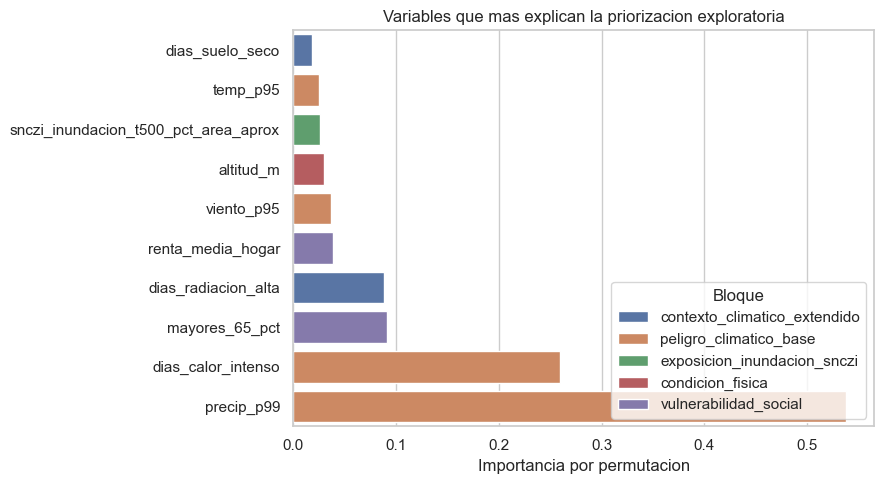

In [15]:
rf_required_files = {
    "importancia": RF_IMPORTANCE_FILE,
    "metricas": RF_METRICS_FILE,
    "importancia_bloques": RF_BLOCK_IMPORTANCE_FILE,
    "predicciones": RF_PREDICTIONS_FILE,
    "metodologia": RF_METHODOLOGY_FILE,
    "estado_shap": RF_SHAP_STATUS_FILE,
}
missing_rf_files = [name for name, path in rf_required_files.items() if not path.exists()]
if missing_rf_files:
    raise FileNotFoundError(
        "Faltan artefactos del Random Forest generados en el Notebook 4: "
        + ", ".join(missing_rf_files)
    )

rf_metrics_business = pd.read_csv(RF_METRICS_FILE)
rf_methodology_business = pd.read_csv(RF_METHODOLOGY_FILE)
rf_importance_business = pd.read_csv(RF_IMPORTANCE_FILE).sort_values(
    "importancia_permutacion_media",
    ascending=False,
).reset_index(drop=True)
rf_block_business = pd.read_csv(RF_BLOCK_IMPORTANCE_FILE).sort_values(
    "importancia_permutacion_media",
    ascending=False,
).reset_index(drop=True)
rf_predictions_business = pd.read_csv(RF_PREDICTIONS_FILE).sort_values(
    "rf_score_riesgo_error_abs",
    ascending=False,
).reset_index(drop=True)
rf_shap_status_business = pd.read_csv(RF_SHAP_STATUS_FILE)
rf_shap_importance_business = None
if RF_SHAP_IMPORTANCE_FILE.exists():
    rf_shap_importance_business = pd.read_csv(RF_SHAP_IMPORTANCE_FILE).sort_values(
        "importancia_shap_media_abs",
        ascending=False,
    ).reset_index(drop=True)

print("Ficha metodologica del Random Forest")
display(rf_methodology_business)

print("Metricas del modelo explicativo")
display(rf_metrics_business.round(4))

print("Top variables que explican el score exploratorio")
display(
    rf_importance_business[
        [
            "ranking_permutacion",
            "variable",
            "bloque",
            "dimension",
            "origen",
            "importancia_permutacion_media",
            "importancia_rf",
        ]
    ].head(12).round(4)
)

print("Importancia agregada por bloque")
display(rf_block_business.round(4))

print("Municipios donde el RF reproduce peor el score exploratorio")
display(
    rf_predictions_business[
        [
            "municipio",
            "score_riesgo_exploratorio",
            "rf_score_riesgo_pred",
            "rf_score_riesgo_residuo",
            "rf_score_riesgo_error_abs",
            "rf_score_split",
        ]
    ].head(10).round(4)
)

print("Estado de SHAP en esta ejecucion")
display(rf_shap_status_business)

if rf_shap_importance_business is not None:
    print("Top variables segun SHAP")
    display(
        rf_shap_importance_business[
            [
                "variable",
                "bloque",
                "dimension",
                "origen",
                "importancia_shap_media_abs",
            ]
        ].head(12).round(4)
    )
else:
    print("Importancia SHAP no disponible; se mantiene permutation importance como explicabilidad principal.")

rf_metrics_lookup = dict(zip(rf_metrics_business["metrica"], rf_metrics_business["valor"]))
top_variables_rf = ", ".join(rf_importance_business["variable"].head(5))
top_variables_shap = "No disponible"
if rf_shap_importance_business is not None:
    top_variables_shap = ", ".join(rf_shap_importance_business["variable"].head(5))
top_block_rf = rf_block_business.iloc[0]
shap_status_label = rf_shap_status_business.loc[0, "estado"]
shap_status_detail = rf_shap_status_business.loc[0, "detalle"]
worst_residual_examples = ", ".join(rf_predictions_business["municipio"].head(5))

rf_business_reading = pd.DataFrame(
    [
        {
            "aspecto": "alcance_modelo",
            "valor": "Random Forest auxiliar sobre score_riesgo_exploratorio",
            "lectura_negocio": "Explica un indice exploratorio municipal; no predice siniestros, primas ni coste esperado.",
        },
        {
            "aspecto": "rendimiento_test",
            "valor": f"R2 test={rf_metrics_lookup.get('R2 test', np.nan):.3f}; MAE test={rf_metrics_lookup.get('MAE test', np.nan):.3f}",
            "lectura_negocio": "El modelo reproduce razonablemente el indice construido, pero esta metrica no valida riesgo asegurador real.",
        },
        {
            "aspecto": "bloque_dominante",
            "valor": f"{top_block_rf['bloque']} ({top_block_rf['peso_permutacion_pct']:.1f}% de la importancia por permutacion)",
            "lectura_negocio": "La lectura del score esta muy condicionada por variables de peligro climatico; exposicion y vulnerabilidad matizan la prioridad.",
        },
        {
            "aspecto": "variables_mas_influyentes",
            "valor": top_variables_rf,
            "lectura_negocio": "Permite explicar a negocio que factores observables empujan mas el ranking municipal.",
        },
        {
            "aspecto": "municipios_mayor_residuo",
            "valor": worst_residual_examples,
            "lectura_negocio": "Son casos utiles para revisar manualmente porque el indice combina senales que el RF reproduce con mas dificultad.",
        },
        {
            "aspecto": "estado_shap",
            "valor": shap_status_label,
            "lectura_negocio": shap_status_detail,
        },
        {
            "aspecto": "variables_mas_influyentes_shap",
            "valor": top_variables_shap,
            "lectura_negocio": "Ranking SHAP medio absoluto de variables; complementa permutation importance sin cambiar el alcance exploratorio.",
        },
    ]
)

rf_business_reading_file = BUSINESS_OUT / "lectura_rf_negocio.csv"
rf_business_reading.to_csv(rf_business_reading_file, index=False)
print("Lectura de negocio del RF guardada en:", rf_business_reading_file)
display(rf_business_reading)

plt.figure(figsize=(9, 5))
top_rf_plot = rf_importance_business.head(10).sort_values("importancia_permutacion_media")
sns.barplot(
    data=top_rf_plot,
    x="importancia_permutacion_media",
    y="variable",
    hue="bloque",
    dodge=False,
)
plt.title("Variables que mas explican la priorizacion exploratoria")
plt.xlabel("Importancia por permutacion")
plt.ylabel("")
plt.legend(title="Bloque", loc="lower right")
plt.tight_layout()
plt.show()


La lectura de importancia confirma que la priorizacion no aparece de forma arbitraria. El peso principal recae en variables de peligro climatico, especialmente precipitacion extrema y calor intenso, lo cual es coherente con el diseno del score. Tambien aparecen variables de vulnerabilidad (`mayores_65_pct`, `renta_media_hogar`) y senales territoriales como altitud y exposicion inundable `SNCZI`.

Desde negocio, esto permite convertir el ranking en una conversacion mas clara: si un municipio aparece priorizado, se puede revisar si el motor principal procede de amenaza climatica, vulnerabilidad, exposicion construida o exposicion inundable. Los municipios con mayor residuo del Random Forest no deben interpretarse como errores de siniestralidad, sino como casos donde el indice combina senales que el modelo reproduce con mas dificultad y que conviene revisar manualmente.

El estado de `SHAP` queda documentado de forma reproducible. Cuando el artefacto `rf_score_shap_importance.csv` esta disponible, se incorpora como una segunda lectura de explicabilidad junto a `permutation importance`. Si no estuviera disponible en otro entorno, la interpretacion seguiria siendo valida con permutation importance, sin afirmar causalidad ni prediccion actuarial.

## 5. Contraste externo con municipios afectados por la DANA 2024

Para reforzar la lectura de negocio se incorpora una referencia externa oficial: el anexo del `Real Decreto-ley 6/2024` publicado en el BOE, que recoge los municipios damnificados por la DANA ocurrida entre el 28 de octubre y el 4 de noviembre de 2024.

Este bloque no convierte el proyecto en un modelo predictivo de siniestralidad. La tabla BOE no contiene polizas, costes, capitales asegurados ni numero de siniestros por hogar. Se utiliza como contraste post-evento: permite observar si los municipios afectados por un episodio real severo aparecen concentrados en determinadas prioridades, clusters o posiciones del ranking exploratorio.

In [16]:
if not DANA_2024_FILE.exists():
    raise FileNotFoundError(
        "No existe la referencia DANA 2024 del BOE. Ejecuta antes scripts/an_negocio/build_dana_2024_reference.py."
    )


def normalize_municipio_name(value: object) -> str:
    text = str(value).lower().strip()
    text = text.replace("\u2019", "'").replace("`", "'").replace("?", "'")
    text = unicodedata.normalize("NFKD", text)
    text = "".join(char for char in text if not unicodedata.combining(char))
    text = text.replace("/", " ")
    text = re.sub(r"[^a-z0-9]+", " ", text)
    text = re.sub(r"\b(l|el|la|les|los|de|del|d)\b", " ", text)
    return re.sub(r"\s+", " ", text).strip()


dana_boe = pd.read_csv(DANA_2024_FILE)
dana_cv_boe = dana_boe.loc[dana_boe["ambito_tfg_cv"].astype(bool)].copy()

df_seg["municipio_key_dana"] = df_seg["municipio"].map(normalize_municipio_name)
dana_cv_boe["municipio_key_dana"] = dana_cv_boe["municipio_boe"].map(normalize_municipio_name)

matched_keys = set(df_seg["municipio_key_dana"])
dana_not_matched = dana_cv_boe.loc[~dana_cv_boe["municipio_key_dana"].isin(matched_keys)]
assert dana_not_matched.empty, "Hay municipios valencianos del BOE sin cruce con la base del TFG."

dana_cols = [
    "municipio_key_dana",
    "municipio_boe",
    "observacion_boe",
    "afectado_dana_2024_boe",
    "periodo_evento",
    "fuente",
    "fuente_url",
]

df_seg = df_seg.merge(dana_cv_boe[dana_cols], on="municipio_key_dana", how="left")
df_seg["afectado_dana_2024_boe"] = df_seg["afectado_dana_2024_boe"].fillna(False).astype(bool)
df_seg["municipio_boe"] = df_seg["municipio_boe"].fillna("")
df_seg["observacion_boe"] = df_seg["observacion_boe"].fillna("")
df_seg["periodo_evento"] = df_seg["periodo_evento"].fillna("")
df_seg["fuente"] = df_seg["fuente"].fillna("")
df_seg["fuente_url"] = df_seg["fuente_url"].fillna("")

affected_col = "afectado_dana_2024_boe"
total_dana_cv = int(df_seg[affected_col].sum())
assert total_dana_cv == len(dana_cv_boe), "El cruce DANA no conserva todos los municipios valencianos del BOE."

df_seg["rank_riesgo_exploratorio"] = df_seg[riesgo_col].rank(method="min", ascending=False).astype(int)

dana_priority_summary = (
    df_seg.groupby("prioridad_negocio", observed=False)
    .agg(
        municipios=("municipio", "count"),
        municipios_dana=(affected_col, "sum"),
        pct_dana_en_prioridad=(affected_col, "mean"),
        riesgo_medio=(riesgo_col, "mean"),
        peligro_medio=(peligro_col, "mean"),
        vulnerabilidad_media=(vulnerabilidad_col, "mean"),
        exposicion_inundacion_media=(exposicion_inundacion_col, "mean"),
        exposicion_fisica_media=(exposicion_col, "mean"),
    )
    .reindex(priority_order)
)
dana_priority_summary["peso_sobre_dana_cv"] = dana_priority_summary["municipios_dana"] / total_dana_cv

dana_cluster_summary = (
    df_seg.groupby(["cluster_kmeans", "perfil_negocio_kmeans"], observed=False)
    .agg(
        municipios=("municipio", "count"),
        municipios_dana=(affected_col, "sum"),
        pct_dana_en_cluster=(affected_col, "mean"),
        riesgo_medio=(riesgo_col, "mean"),
        exposicion_inundacion_media=(exposicion_inundacion_col, "mean"),
        exposicion_fisica_media=(exposicion_col, "mean"),
    )
    .reset_index()
    .sort_values("municipios_dana", ascending=False)
)
dana_cluster_summary["peso_sobre_dana_cv"] = dana_cluster_summary["municipios_dana"] / total_dana_cv

dana_overlap_metrics = pd.DataFrame(
    [
        {
            "metrica": "Municipios BOE en ambito CV",
            "valor": total_dana_cv,
            "lectura": "Municipios valencianos del anexo oficial que cruzan con la base municipal del TFG.",
        },
        {
            "metrica": "DANA en prioridad Muy alta o Alta",
            "valor": int(df_seg.loc[df_seg[affected_col], "prioridad_negocio"].isin(["Muy alta", "Alta"]).sum()),
            "lectura": "Municipios afectados que el modelo exploratorio situa en prioridad operativa superior.",
        },
        {
            "metrica": "Porcentaje DANA en Muy alta o Alta",
            "valor": df_seg.loc[df_seg[affected_col], "prioridad_negocio"].isin(["Muy alta", "Alta"]).mean(),
            "lectura": "Solape relativo entre evento oficial y cola prioritaria del TFG.",
        },
        {
            "metrica": "Mediana ranking riesgo en municipios DANA",
            "valor": df_seg.loc[df_seg[affected_col], "rank_riesgo_exploratorio"].median(),
            "lectura": "Posicion central de los municipios afectados dentro del ranking de 542 municipios.",
        },
    ]
)

dana_affected_ranking = (
    df_seg.loc[df_seg[affected_col]]
    .sort_values("rank_riesgo_exploratorio")
    [
        [
            "municipio",
            "municipio_boe",
            "prioridad_negocio",
            "cluster_kmeans",
            "perfil_negocio_kmeans",
            "rank_riesgo_exploratorio",
            riesgo_col,
            peligro_col,
            vulnerabilidad_col,
            exposicion_inundacion_col,
            exposicion_col,
            dominant_dimension_col,
            "observacion_boe",
        ]
    ]
)

dana_validation_cols = [
    "municipio",
    "municipio_boe",
    affected_col,
    "prioridad_negocio",
    "cluster_kmeans",
    "perfil_negocio_kmeans",
    "rank_riesgo_exploratorio",
    riesgo_col,
    peligro_col,
    vulnerabilidad_col,
    exposicion_inundacion_col,
    exposicion_col,
    dominant_dimension_col,
    "periodo_evento",
    "fuente",
    "fuente_url",
]

df_seg[dana_validation_cols].to_csv(BUSINESS_OUT / "dana_2024_validacion_municipal.csv", index=False)
dana_priority_summary.round(4).to_csv(BUSINESS_OUT / "dana_2024_resumen_prioridad.csv")
dana_cluster_summary.round(4).to_csv(BUSINESS_OUT / "dana_2024_resumen_cluster.csv", index=False)
dana_overlap_metrics.to_csv(BUSINESS_OUT / "dana_2024_metricas_contraste.csv", index=False)

print("Municipios valencianos BOE cruzados:", total_dana_cv)
print("Salidas guardadas en:", BUSINESS_OUT)
display(dana_overlap_metrics)
display(dana_priority_summary.round(4))
display(dana_cluster_summary.round(4))
print("Municipios DANA mejor posicionados en el ranking exploratorio")
display(dana_affected_ranking.head(20).round(4))


Municipios valencianos BOE cruzados: 75
Salidas guardadas en: C:\Users\gonza\OneDrive\tfg\output\negocio


,metrica,valor,lectura
0,Municipios BOE en ambito CV,75.000000,Municipios valencianos del anexo oficial que c...
1,DANA en prioridad Muy alta o Alta,22.000000,Municipios afectados que el modelo exploratori...
2,Porcentaje DANA en Muy alta o Alta,0.293333,Solape relativo entre evento oficial y cola pr...
3,Mediana ranking riesgo en municipios DANA,273.000000,Posicion central de los municipios afectados d...


,municipios,municipios_dana,pct_dana_en_prioridad,riesgo_medio,peligro_medio,vulnerabilidad_media,exposicion_inundacion_media,exposicion_fisica_media,peso_sobre_dana_cv
prioridad_negocio,,,,,,,,,
Muy alta,93,18,0.1935,0.3791,0.4612,0.4134,0.2139,0.1224,0.2400
Alta,52,4,0.0769,0.3600,0.4589,0.4010,0.0793,0.0514,0.0533
Media,126,15,0.1190,0.3274,0.3949,0.4024,0.0717,0.0462,0.2000
Baja,271,38,0.1402,0.2676,0.3000,0.3753,0.0297,0.0250,0.5067


,cluster_kmeans,perfil_negocio_kmeans,municipios,municipios_dana,pct_dana_en_cluster,riesgo_medio,exposicion_inundacion_media,exposicion_fisica_media,peso_sobre_dana_cv
0,0,Areas urbanas o litorales con exposicion fisic...,141,42,0.2979,0.3168,0.2293,0.1458,0.5600
2,2,Peligro climatico alto con exposicion moderada...,131,18,0.1374,0.3305,0.0200,0.0165,0.2400
1,1,Interior rural de baja exposicion y mayor altitud,205,11,0.0537,0.2863,0.0030,0.0037,0.1467
3,3,Municipios calidos y secos con exposicion hidr...,65,4,0.0615,0.3244,0.0850,0.0490,0.0533


Municipios DANA mejor posicionados en el ranking exploratorio


,municipio,municipio_boe,prioridad_negocio,cluster_kmeans,perfil_negocio_kmeans,rank_riesgo_exploratorio,score_riesgo_exploratorio,score_peligro_climatico_ampliado,score_vulnerabilidad,score_exposicion_inundacion,score_exposicion_fisica,dimension_dominante_score,observacion_boe
92,Benetússer,Benetússer,Muy alta,0,Areas urbanas o litorales con exposicion fisic...,2,0.4463,0.3478,0.6253,0.0902,0.4241,vulnerabilidad,
290,Mislata,Mislata,Muy alta,0,Areas urbanas o litorales con exposicion fisic...,4,0.4235,0.3272,0.6356,0.0972,0.3462,vulnerabilidad,
267,Llocnou de la Corona,Llocnou de la Corona,Muy alta,0,Areas urbanas o litorales con exposicion fisic...,11,0.4037,0.3478,0.4382,0.0000,0.4914,peligro climatico,
347,Polinyà de Xúquer,Polinyà de Xúquer,Muy alta,0,Areas urbanas o litorales con exposicion fisic...,14,0.4017,0.4321,0.3426,1.0000,0.4142,peligro climatico,
12,Albalat de la Ribera,Albalat de la Ribera,Muy alta,0,Areas urbanas o litorales con exposicion fisic...,24,0.3895,0.4321,0.3580,0.7966,0.3305,peligro climatico,
232,Fortaleny,Fortaleny,Muy alta,0,Areas urbanas o litorales con exposicion fisic...,26,0.3878,0.4126,0.3494,0.9282,0.3833,peligro climatico,
40,Algemesí,Algemesí,Muy alta,0,Areas urbanas o litorales con exposicion fisic...,37,0.3812,0.4321,0.3269,0.7826,0.3354,peligro climatico,
101,Benicull de Xúquer,Benicull de Xúquer,Muy alta,0,Areas urbanas o litorales con exposicion fisic...,41,0.3795,0.4321,0.3382,0.7295,0.3099,peligro climatico,
370,Riola,Riola,Muy alta,0,Areas urbanas o litorales con exposicion fisic...,46,0.3783,0.4126,0.3554,0.7817,0.3270,peligro climatico,
202,Cullera,Cullera,Muy alta,0,Areas urbanas o litorales con exposicion fisic...,55,0.3760,0.4126,0.3722,0.6708,0.2901,peligro climatico,


El contraste DANA aporta una comprobacion externa util, pero limitada. Si una parte relevante de los municipios afectados aparece en prioridades altas o en perfiles con exposicion inundable, el modelo gana coherencia territorial. Si no ocurre, tambien es informacion valiosa: indica que el score abierto mide exposicion relativa estructural, no dano asegurado real ni intensidad local del evento.

Por tanto, este bloque se interpreta como validacion cualitativa post-evento. Para evaluar capacidad predictiva real harian falta siniestros, importes, polizas y capitales asegurados a escala municipal o geocodificada.

## 6. Representacion espacial de prioridades y perfiles de negocio

La lectura de negocio gana fuerza cuando los perfiles y prioridades identificados se trasladan al espacio geografico. En este bloque se representan los clusters principales, la prioridad operativa y el score de riesgo exploratorio para comprobar si existen concentraciones territoriales, continuidades espaciales o contrastes relevantes entre zonas.

El objetivo no es producir una zonificacion definitiva del riesgo asegurador, sino aportar una evidencia visual que ayude a interpretar mejor donde se concentran los perfiles municipales mas sensibles desde la perspectiva del negocio.

In [17]:
gdf_business = gpd.read_file(MUNICIPIOS_GEO_FILE).merge(
    df_seg[
        [
            "municipio",
            "CODNUT2",
            "CODNUT3",
            "cluster_kmeans",
            "perfil_negocio_kmeans",
            "prioridad_negocio",
            riesgo_col,
            peligro_col,
            vulnerabilidad_col,
            exposicion_col,
            dominant_dimension_col,
        ]
    ],
    on=["municipio", "CODNUT2", "CODNUT3"],
    how="left",
)

print("Municipios en geometria:", len(gdf_business))
print("Municipios con prioridad asignada:", gdf_business["prioridad_negocio"].notna().sum())
display(gdf_business[["municipio", "cluster_kmeans", "prioridad_negocio", riesgo_col]].head())

Municipios en geometria: 542
Municipios con prioridad asignada: 542


,municipio,cluster_kmeans,prioridad_negocio,score_riesgo_exploratorio
0,l'Atzúbia,2,Muy alta,0.405777
1,Agost,3,Baja,0.301895
2,Agres,2,Media,0.310747
3,Aigües,3,Baja,0.272103
4,Albatera,3,Baja,0.291777


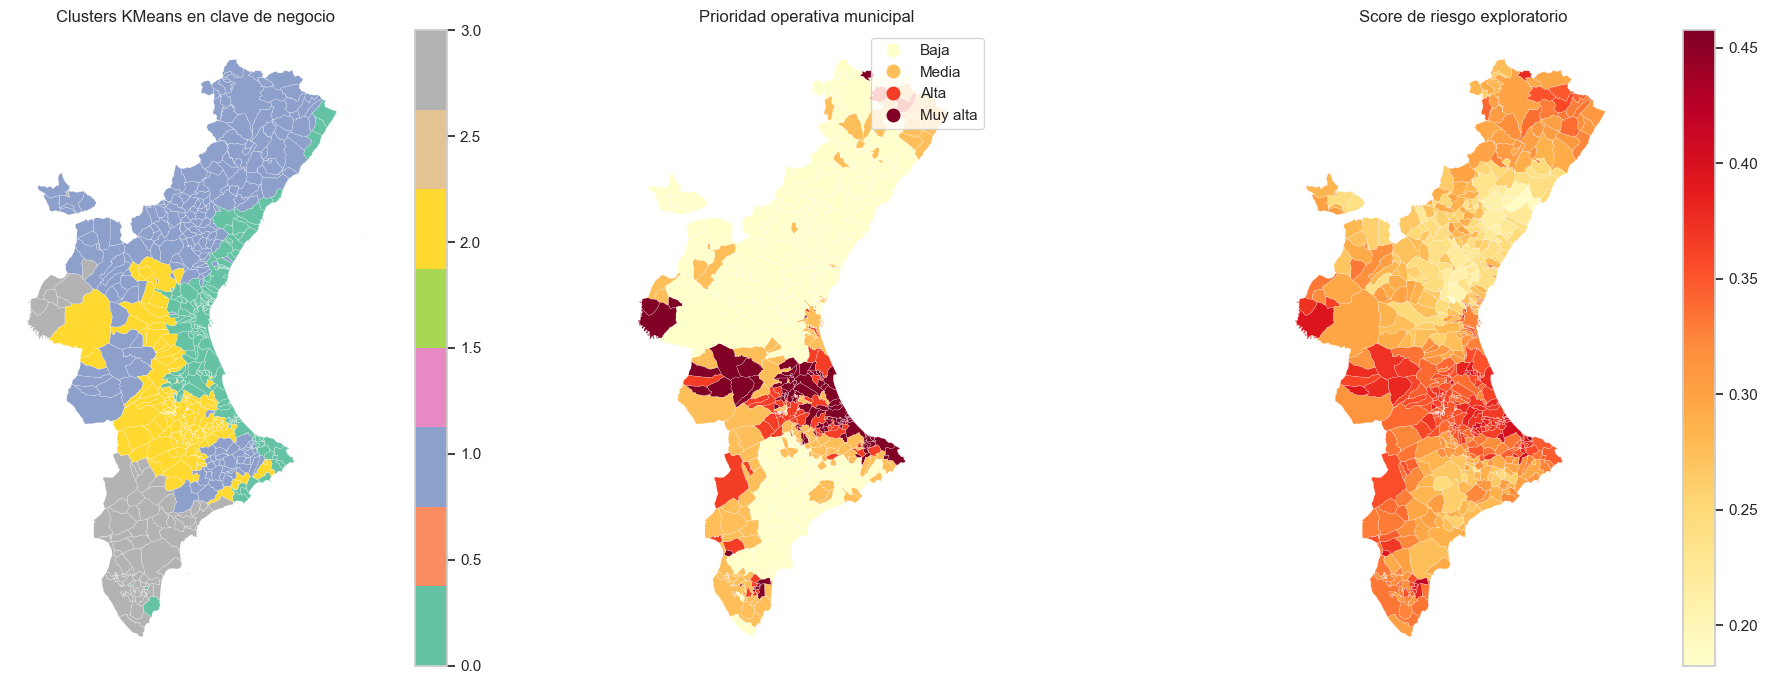

In [18]:
map_priority_order = ["Baja", "Media", "Alta", "Muy alta"]
gdf_business["prioridad_negocio"] = pd.Categorical(
    gdf_business["prioridad_negocio"],
    categories=map_priority_order,
    ordered=True,
)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

gdf_business.plot(
    column="cluster_kmeans",
    cmap="Set2",
    legend=True,
    ax=axes[0],
    linewidth=0.15,
    edgecolor="white",
    missing_kwds={"color": "lightgrey", "label": "Sin datos"},
)
axes[0].set_title("Clusters KMeans en clave de negocio")
axes[0].axis("off")

gdf_business.plot(
    column="prioridad_negocio",
    cmap="YlOrRd",
    legend=True,
    ax=axes[1],
    linewidth=0.15,
    edgecolor="white",
    missing_kwds={"color": "lightgrey", "label": "Sin datos"},
)
axes[1].set_title("Prioridad operativa municipal")
axes[1].axis("off")

gdf_business.plot(
    column=riesgo_col,
    cmap="YlOrRd",
    legend=True,
    ax=axes[2],
    linewidth=0.15,
    edgecolor="white",
    missing_kwds={"color": "lightgrey", "label": "Sin datos"},
)
axes[2].set_title("Score de riesgo exploratorio")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [19]:
priority_by_cluster = (
    df_seg.groupby(["cluster_kmeans", "prioridad_negocio"], observed=False)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=priority_order, fill_value=0)
)

display(priority_by_cluster)

priority_by_cluster_pct = (
    priority_by_cluster
    .div(priority_by_cluster.sum(axis=1), axis=0)
    .mul(100)
    .round(1)
)

display(priority_by_cluster_pct)

prioridad_negocio,Muy alta,Alta,Media,Baja
cluster_kmeans,,,,
0,49,8,23,61
1,13,6,37,149
2,24,30,38,39
3,7,8,28,22


prioridad_negocio,Muy alta,Alta,Media,Baja
cluster_kmeans,,,,
0,34.8,5.7,16.3,43.3
1,6.3,2.9,18.0,72.7
2,18.3,22.9,29.0,29.8
3,10.8,12.3,43.1,33.8


### 6.1 Municipios singulares segun DBSCAN

Los municipios clasificados como ruido por `DBSCAN` no se interpretan como errores, sino como observaciones que no encajan claramente en los nucleos densos detectados por localizacion y riesgo exploratorio. En negocio pueden servir como una lista de casos a revisar individualmente cuando coinciden con prioridades elevadas.

In [20]:
dbscan_singularity_table = (
    df_seg.assign(es_ruido_dbscan=df_seg["cluster_dbscan"].eq(-1))
    .groupby(["es_ruido_dbscan", "prioridad_negocio"], observed=False)
    .agg(
        municipios=("municipio", "count"),
        riesgo_medio=(riesgo_col, "mean"),
        peligro_medio=(peligro_col, "mean"),
        vulnerabilidad_media=(vulnerabilidad_col, "mean"),
        exposicion_media=(exposicion_col, "mean"),
    )
    .round(3)
    .reset_index()
)

display(dbscan_singularity_table)

dbscan_priority_cases = (
    df_seg.loc[df_seg["cluster_dbscan"].eq(-1), [
        "municipio",
        "cluster_kmeans",
        "perfil_negocio_kmeans",
        "prioridad_negocio",
        riesgo_col,
        peligro_col,
        vulnerabilidad_col,
        exposicion_col,
        dominant_dimension_col,
    ]]
    .sort_values(["prioridad_negocio", riesgo_col], ascending=[True, False])
    .head(15)
)

display(dbscan_priority_cases)

,es_ruido_dbscan,prioridad_negocio,municipios,riesgo_medio,peligro_medio,vulnerabilidad_media,exposicion_media
0,False,Muy alta,73,0.374,0.475,0.384,0.106
1,False,Alta,47,0.360,0.464,0.392,0.049
2,False,Media,114,0.327,0.398,0.398,0.045
3,False,Baja,249,0.268,0.301,0.373,0.026
4,True,Muy alta,20,0.398,0.411,0.520,0.181
5,True,Alta,5,0.364,0.409,0.484,0.072
6,True,Media,12,0.327,0.366,0.444,0.055
7,True,Baja,22,0.266,0.284,0.405,0.012


,municipio,cluster_kmeans,perfil_negocio_kmeans,prioridad_negocio,score_riesgo_exploratorio,score_peligro_climatico_ampliado,score_vulnerabilidad,score_exposicion_fisica,dimension_dominante_score
500,els Poblets,0,Areas urbanas o litorales con exposicion fisic...,Muy alta,0.457419,0.474477,0.484944,0.373485,peligro climatico
92,Benetússer,0,Areas urbanas o litorales con exposicion fisic...,Muy alta,0.446333,0.347842,0.625274,0.424149,vulnerabilidad
215,Emperador,0,Areas urbanas o litorales con exposicion fisic...,Muy alta,0.427266,0.345037,0.550293,0.448299,peligro climatico
290,Mislata,0,Areas urbanas o litorales con exposicion fisic...,Muy alta,0.423518,0.327184,0.635632,0.346185,vulnerabilidad
384,San Fulgencio,3,Municipios calidos y secos con exposicion hidr...,Muy alta,0.414058,0.399722,0.605117,0.163312,peligro climatico
267,Llocnou de la Corona,0,Areas urbanas o litorales con exposicion fisic...,Muy alta,0.403668,0.347842,0.438218,0.491411,peligro climatico
207,Daya Vieja,3,Municipios calidos y secos con exposicion hidr...,Muy alta,0.403610,0.399722,0.530021,0.223714,peligro climatico
121,Benimuslem,0,Areas urbanas o litorales con exposicion fisic...,Muy alta,0.401109,0.444655,0.353480,0.363687,peligro climatico
231,Formentera del Segura,0,Areas urbanas o litorales con exposicion fisic...,Muy alta,0.397574,0.399722,0.428876,0.345249,peligro climatico
456,Venta del Moro,3,Municipios calidos y secos con exposicion hidr...,Muy alta,0.395655,0.463267,0.546350,0.000585,peligro climatico


La representacion espacial permite comprobar que las prioridades no se distribuyen de forma aleatoria, sino que responden a combinaciones territoriales concretas de clima, vulnerabilidad y exposicion. Esta lectura resulta especialmente util para pasar de una lista de municipios a una interpretacion espacial mas cercana a decisiones de vigilancia, seguimiento o segmentacion de cartera.

Ademas, el cruce entre clusters y prioridad operativa ayuda a entender que una misma prioridad puede responder a logicas distintas: en algunos casos pesa mas la peligrosidad climatica, en otros la vulnerabilidad demografica o la exposicion urbana. Esta distincion es relevante porque sugiere que las posibles respuestas de negocio tampoco deberian ser identicas en todos los territorios.

La prueba con `DBSCAN` refuerza esta idea desde otro angulo: no todos los municipios encajan en agrupaciones densas, por lo que algunos territorios deben tratarse como casos singulares y no solo como miembros de un perfil medio.

## 7. Implicaciones para una aseguradora

A partir de los perfiles municipales, de los rankings y de la prioridad operativa construida en los bloques anteriores, es posible extraer una primera lectura orientada a negocio. Esta lectura no sustituye un modelo actuarial ni una politica tarifaria real, pero si permite plantear usos potenciales del analisis para prevencion, seguimiento territorial y segmentacion de cartera.

El interes principal de este bloque reside en traducir los resultados tecnicos a preguntas mas proximas a la decision: que territorios merecen mayor vigilancia, donde pueden concentrarse riesgos emergentes, y que perfiles municipales podrian justificar estrategias diferenciales de seguimiento o profundizacion analitica.

La descomposicion del score ayuda a convertir la prioridad en una hipotesis accionable: no todos los municipios prioritarios requieren el mismo tipo de contraste interno.

In [21]:
priority_business_table = (
    df_seg.groupby("prioridad_negocio", observed=False)
    .agg(
        municipios=("municipio", "count"),
        poblacion_total=("poblacion_total", "sum"),
        riesgo_medio=(riesgo_col, "mean"),
        peligro_medio=(peligro_col, "mean"),
        vulnerabilidad_media=(vulnerabilidad_col, "mean"),
        exposicion_construida_media=(exposicion_construida_col, "mean"),
        exposicion_inundacion_media=(exposicion_inundacion_col, "mean"),
        exposicion_media=(exposicion_col, "mean"),
        densidad_viviendas_media=("densidad_viviendas_catastro_km2", "mean"),
        contrib_peligro_medio=("contrib_peligro_climatico", "mean"),
        contrib_vulnerabilidad_media=("contrib_vulnerabilidad", "mean"),
        contrib_exposicion_media=("contrib_exposicion_fisica", "mean"),
    )
    .round(3)
    .reindex(priority_order)
)

display(priority_business_table)

,municipios,poblacion_total,riesgo_medio,peligro_medio,vulnerabilidad_media,exposicion_construida_media,exposicion_inundacion_media,exposicion_media,densidad_viviendas_media,contrib_peligro_medio,contrib_vulnerabilidad_media,contrib_exposicion_media
prioridad_negocio,,,,,,,,,,,,
Muy alta,93,595712.0,0.379,0.461,0.413,0.061,0.214,0.122,649.702,0.231,0.124,0.024
Alta,52,283091.0,0.360,0.459,0.401,0.033,0.079,0.051,336.730,0.229,0.120,0.010
Media,126,1796844.0,0.327,0.395,0.402,0.029,0.072,0.046,282.431,0.197,0.121,0.009
Baja,271,2740196.0,0.268,0.300,0.375,0.022,0.030,0.025,191.988,0.150,0.113,0.005


### 7.1 Matriz de implicaciones aseguradoras

La tabla siguiente aterriza los resultados en usos potenciales. Se formula en terminos de preguntas y evidencias necesarias para evitar presentar conclusiones que el proyecto no puede sostener sin datos internos.

In [22]:
insurance_use_case_matrix = pd.DataFrame(
    [
        {
            "linea": "Vigilancia territorial",
            "pregunta_de_negocio": "Donde conviene revisar primero la exposicion y el historico de eventos?",
            "evidencia_del_tfg": "prioridad_negocio, score_riesgo_exploratorio, score_exposicion_inundacion, mapas y clusters KMeans",
            "dato_interno_para_decidir": "Siniestros, polizas vigentes, capital asegurado y concentracion de cartera.",
        },
        {
            "linea": "Prevencion segmentada",
            "pregunta_de_negocio": "Que tipo de comunicacion preventiva tendria mas sentido por perfil municipal?",
            "evidencia_del_tfg": "perfil_negocio_kmeans, peligro climatico, vulnerabilidad, exposicion construida y exposicion inundable",
            "dato_interno_para_decidir": "Tipo de cliente, uso del inmueble, coberturas, medidas de proteccion y canal de contacto.",
        },
        {
            "linea": "Segmentacion territorial de cartera",
            "pregunta_de_negocio": "Como agrupar municipios para analizar cartera y acumulacion de exposicion?",
            "evidencia_del_tfg": "clusters KMeans y contraste Agglomerative/DBSCAN",
            "dato_interno_para_decidir": "Distribucion real de polizas, capitales, primas, siniestros y actividad asegurada.",
        },
        {
            "linea": "Enriquecimiento futuro",
            "pregunta_de_negocio": "Que datos adicionales aportarian mas valor al siguiente ciclo analitico?",
            "evidencia_del_tfg": "municipios prioritarios, casos tipo, motor dominante del score y limitaciones detectadas",
            "dato_interno_para_decidir": "Causas de siniestro, severidad, coste, geocodificacion de cartera y exposicion asegurada.",
        },
    ]
)

display(insurance_use_case_matrix)

,linea,pregunta_de_negocio,evidencia_del_tfg,dato_interno_para_decidir
0,Vigilancia territorial,Donde conviene revisar primero la exposicion y...,"prioridad_negocio, score_riesgo_exploratorio, ...","Siniestros, polizas vigentes, capital asegurad..."
1,Prevencion segmentada,Que tipo de comunicacion preventiva tendria ma...,"perfil_negocio_kmeans, peligro climatico, vuln...","Tipo de cliente, uso del inmueble, coberturas,..."
2,Segmentacion territorial de cartera,Como agrupar municipios para analizar cartera ...,clusters KMeans y contraste Agglomerative/DBSCAN,"Distribucion real de polizas, capitales, prima..."
3,Enriquecimiento futuro,Que datos adicionales aportarian mas valor al ...,"municipios prioritarios, casos tipo, motor dom...","Causas de siniestro, severidad, coste, geocodi..."


### 7.2 Recomendaciones ejecutivas priorizadas

La matriz anterior describe usos potenciales. Para reforzar la capacidad de recomendacion, se traduce ahora esa lectura en acciones priorizadas. Las recomendaciones se formulan como decisiones analiticas de seguimiento, no como decisiones automaticas de precio o aceptacion de riesgo.

In [23]:
top_priority_municipalities = int(df_seg["prioridad_negocio"].astype(str).isin(["Muy alta", "Alta"]).sum())
rf_top_variables = ", ".join(rf_importance_business.head(3)["variable"].tolist())
dana_high_priority = int(
    df_seg.loc[df_seg[affected_col], "prioridad_negocio"]
    .astype(str)
    .isin(["Muy alta", "Alta"])
    .sum()
)
dana_low_priority = int(
    (
        df_seg[affected_col]
        & df_seg["prioridad_negocio"].astype(str).eq("Baja")
    ).sum()
)
cluster_0_dana = int(
    (
        df_seg[affected_col]
        & df_seg["cluster_kmeans"].eq(0)
    ).sum()
)

executive_recommendation_table = pd.DataFrame(
    [
        {
            "prioridad": 1,
            "accion_recomendada": "Revisar primero municipios con prioridad Muy alta o Alta",
            "criterio_de_activacion": f"{top_priority_municipalities} municipios quedan en la cola superior de seguimiento.",
            "evidencia_del_tfg": "score_riesgo_exploratorio, prioridad_negocio y dimension dominante del score",
            "dato_necesario_para_operar": "Polizas, capital asegurado, siniestros historicos y exposicion de cartera por municipio.",
            "valor_para_negocio": "Convierte el analisis territorial en una cola inicial de revision.",
        },
        {
            "prioridad": 2,
            "accion_recomendada": "Analizar de forma especifica el cluster de exposicion fisica e inundable elevada",
            "criterio_de_activacion": f"{cluster_0_dana} municipios DANA 2024 aparecen en este perfil territorial.",
            "evidencia_del_tfg": "cluster_kmeans, score_exposicion_inundacion, Catastro y SNCZI",
            "dato_necesario_para_operar": "Capitales asegurados, uso del inmueble, antiguedad, medidas de proteccion y concentracion de cartera.",
            "valor_para_negocio": "Ayuda a priorizar zonas donde exposicion fisica e inundable pueden amplificar el impacto.",
        },
        {
            "prioridad": 3,
            "accion_recomendada": "Usar las variables explicativas principales como senales de vigilancia",
            "criterio_de_activacion": f"Variables mas relevantes del RF auxiliar: {rf_top_variables}.",
            "evidencia_del_tfg": "rf_score_feature_importance y permutation importance",
            "dato_necesario_para_operar": "Umbrales internos de alerta, historico de eventos y respuesta operacional ante episodios extremos.",
            "valor_para_negocio": "Permite pasar de un ranking estatico a hipotesis de seguimiento climatico.",
        },
        {
            "prioridad": 4,
            "accion_recomendada": "Tratar los municipios singulares DBSCAN como casos para revision cualitativa",
            "criterio_de_activacion": "Municipios etiquetados como ruido o singulares dentro de la estructura espacial.",
            "evidencia_del_tfg": "cluster_dbscan, mapas y ranking operativo",
            "dato_necesario_para_operar": "Conocimiento territorial, cartera local y validacion con equipos tecnicos o mediadores.",
            "valor_para_negocio": "Detecta casos que pueden no encajar bien en perfiles medios y merecen lectura individual.",
        },
        {
            "prioridad": 5,
            "accion_recomendada": "Investigar municipios DANA 2024 no priorizados por el score",
            "criterio_de_activacion": f"{dana_low_priority} municipios afectados por DANA aparecen con prioridad Baja.",
            "evidencia_del_tfg": "contraste DANA 2024, prioridad_negocio y ranking de riesgo",
            "dato_necesario_para_operar": "Huella real del evento, intensidad local, danos reportados y exposicion asegurada.",
            "valor_para_negocio": "Evita sobreinterpretar el score y convierte discrepancias en aprendizaje metodologico.",
        },
    ]
)

display(executive_recommendation_table)
executive_recommendation_table.to_csv(BUSINESS_OUT / "recomendaciones_ejecutivas_negocio.csv", index=False)


,prioridad,accion_recomendada,criterio_de_activacion,evidencia_del_tfg,dato_necesario_para_operar,valor_para_negocio
0,1,Revisar primero municipios con prioridad Muy a...,145 municipios quedan en la cola superior de s...,"score_riesgo_exploratorio, prioridad_negocio y...","Polizas, capital asegurado, siniestros histori...",Convierte el analisis territorial en una cola ...
1,2,Analizar de forma especifica el cluster de exp...,42 municipios DANA 2024 aparecen en este perfi...,"cluster_kmeans, score_exposicion_inundacion, C...","Capitales asegurados, uso del inmueble, antigu...",Ayuda a priorizar zonas donde exposicion fisic...
2,3,Usar las variables explicativas principales co...,Variables mas relevantes del RF auxiliar: prec...,rf_score_feature_importance y permutation impo...,"Umbrales internos de alerta, historico de even...",Permite pasar de un ranking estatico a hipotes...
3,4,Tratar los municipios singulares DBSCAN como c...,Municipios etiquetados como ruido o singulares...,"cluster_dbscan, mapas y ranking operativo","Conocimiento territorial, cartera local y vali...",Detecta casos que pueden no encajar bien en pe...
4,5,Investigar municipios DANA 2024 no priorizados...,38 municipios afectados por DANA aparecen con ...,"contraste DANA 2024, prioridad_negocio y ranki...","Huella real del evento, intensidad local, dano...",Evita sobreinterpretar el score y convierte di...


Desde una perspectiva aseguradora, los resultados sugieren al menos cuatro lineas de utilidad potencial:

1. **Vigilancia territorial reforzada**: los municipios con prioridad `Muy alta` o `Alta` pueden considerarse candidatos para seguimiento especifico, revision periodica o analisis territorial adicional, especialmente cuando combinan peligro climatico elevado con vulnerabilidad social, exposicion construida o exposicion inundable.

2. **Prevencion y comunicacion segmentada**: los perfiles identificados permiten imaginar acciones preventivas diferenciadas. Por ejemplo, los clusters mas ligados a precipitacion extrema, calor o sequedad pueden asociarse a recomendaciones de prevencion climatica, mientras que los perfiles urbanos o inundables de alta exposicion pueden orientar acciones sobre continuidad operativa, mantenimiento preventivo o concentracion de capital expuesto.

3. **Segmentacion territorial de cartera**: aunque el trabajo no dispone de siniestros reales ni de primas, la tipologia municipal construida puede servir como capa auxiliar para segmentar territorios y priorizar donde conviene profundizar con informacion interna de exposicion, polizas o historicidad de eventos.

4. **Priorizacion de futuras integraciones de datos**: los municipios destacados por riesgo, peligro, vulnerabilidad, exposicion construida o exposicion inundable ofrecen una base razonable para decidir donde seria mas valioso incorporar nuevas fuentes, como siniestros reales, capitales asegurados, usos del inmueble, tipologia de poliza o detalle de cartera.

La aportacion principal no es cerrar una decision aseguradora, sino transformar datos abiertos en un mapa razonado de preguntas: donde mirar primero, que dimension revisar y que dato faltante seria mas valioso.

In [24]:
casos_tipo_negocio = (
    df_seg[
        [
            "municipio",
            "cluster_kmeans",
            "perfil_negocio_kmeans",
            "prioridad_negocio",
            riesgo_col,
            peligro_col,
            vulnerabilidad_col,
            exposicion_construida_col,
            exposicion_inundacion_col,
            exposicion_col,
            snczi_t100_col,
            snczi_t500_col,
            *score_contribution_cols,
            dominant_dimension_col,
            "densidad_poblacion",
            "densidad_viviendas_catastro_km2",
            "ratio_huella_edificada_pct",
            "mayores_65_pct",
            "renta_media_hogar",
        ]
    ]
    .sort_values(["prioridad_negocio", riesgo_col], ascending=[True, False])
    .groupby("perfil_negocio_kmeans")
    .head(2)
)

display(casos_tipo_negocio)

,municipio,cluster_kmeans,perfil_negocio_kmeans,prioridad_negocio,score_riesgo_exploratorio,score_peligro_climatico_ampliado,score_vulnerabilidad,score_exposicion_construida,score_exposicion_inundacion,score_exposicion_fisica,snczi_inundacion_t100_pct_area_aprox,snczi_inundacion_t500_pct_area_aprox,contrib_peligro_climatico,contrib_vulnerabilidad,contrib_exposicion_fisica,dimension_dominante_score,densidad_poblacion,densidad_viviendas_catastro_km2,ratio_huella_edificada_pct,mayores_65_pct,renta_media_hogar
500,els Poblets,0,Areas urbanas o litorales con exposicion fisic...,Muy alta,0.457419,0.474477,0.484944,0.106444,0.774048,0.373485,0.637413,0.737875,0.237238,0.145483,0.074697,peligro climatico,748.17,775.03,8.7663,35.28,31207.0
92,Benetússer,0,Areas urbanas o litorales con exposicion fisic...,Muy alta,0.446333,0.347842,0.625274,0.646767,0.090222,0.424149,0.000000,0.167598,0.173921,0.187582,0.084830,vulnerabilidad,21451.10,9253.94,51.6428,19.36,32367.0
384,San Fulgencio,3,Municipios calidos y secos con exposicion hidr...,Muy alta,0.414058,0.399722,0.605117,0.062369,0.314726,0.163312,0.013307,0.570026,0.199861,0.181535,0.032662,peligro climatico,471.80,504.89,4.6938,42.84,23694.0
507,l'Atzúbia,2,Peligro climatico alto con exposicion moderada...,Muy alta,0.405777,0.519953,0.483333,0.006673,0.000000,0.004004,0.000000,0.000000,0.259976,0.145000,0.000801,peligro climatico,40.12,40.40,0.5672,35.94,30891.0
21,Alcalalí,1,Interior rural de baja exposicion y mayor altitud,Muy alta,0.405476,0.474477,0.550479,0.011805,0.020968,0.015470,0.016067,0.021306,0.237238,0.165144,0.003094,peligro climatico,99.19,73.77,1.0291,40.85,27781.0
100,Benicolet,2,Peligro climatico alto con exposicion moderada...,Muy alta,0.404239,0.523869,0.459171,0.007183,0.046132,0.022763,0.037902,0.044072,0.261935,0.137751,0.004553,peligro climatico,53.82,34.68,0.7769,31.98,29760.0
207,Daya Vieja,3,Municipios calidos y secos con exposicion hidr...,Muy alta,0.403610,0.399722,0.530021,0.023501,0.524035,0.223714,0.103834,0.859425,0.199861,0.159006,0.044743,peligro climatico,221.92,176.77,2.5698,38.80,28386.0
485,Zarra,1,Interior rural de baja exposicion y mayor altitud,Muy alta,0.391350,0.429470,0.588241,0.001189,0.000000,0.000714,0.000000,0.000000,0.214735,0.176472,0.000143,peligro climatico,7.52,6.20,0.1495,42.26,24395.0


La tabla de casos tipo ayuda a aterrizar el analisis en ejemplos concretos. En lugar de quedarse en clusters abstractos, permite visualizar municipios que representan perfiles distintos de negocio: territorios con mayor peligro climatico, municipios expuestos por densidad construida o por zonas inundables, zonas interiores envejecidas o combinaciones de calor, sequedad y vulnerabilidad.

Esta lectura no basta por si sola para definir acciones comerciales o tarifarias, pero si aporta una base argumental util para justificar donde podria concentrarse primero un esfuerzo adicional de analisis, prevencion o enriquecimiento de informacion interna.

### 7.3 Cierre frente a la rubrica de negocio

La rubrica de Analisis de Negocio valora especialmente que el trabajo responda a los objetivos planteados, traduzca los resultados en conclusiones claras y proponga recomendaciones aplicables. Por ello, antes de exportar el paquete final, se resume la lectura de negocio en una tabla de cierre.

Esta tabla no anade un modelo nuevo: organiza la evidencia ya obtenida en el formato `objetivo -> resultado -> conclusion -> recomendacion -> limitacion`, que es el puente entre el analisis tecnico y la toma de decisiones.


In [25]:
dana_high_value = int(
    dana_overlap_metrics.loc[
        dana_overlap_metrics["metrica"] == "DANA en prioridad Muy alta o Alta",
        "valor",
    ].iloc[0]
)
dana_high_pct = float(
    dana_overlap_metrics.loc[
        dana_overlap_metrics["metrica"] == "Porcentaje DANA en Muy alta o Alta",
        "valor",
    ].iloc[0]
)
priority_high_count = int(df_seg["prioridad_negocio"].isin(["Muy alta", "Alta"]).sum())

rubrica_business_closure = pd.DataFrame(
    [
        {
            "criterio_rubrica": "Respuesta a objetivos y preguntas",
            "objetivo_pregunta": "Aproximar el riesgo climatico territorial en seguros de hogar con datos abiertos.",
            "evidencia_resultado": f"542 municipios priorizados; {priority_high_count} municipios en prioridad Muy alta o Alta.",
            "conclusion_negocio": "El TFG permite ordenar territorios y detectar perfiles municipales de seguimiento, aunque no estime siniestralidad real.",
            "recomendacion_accionable": "Usar el ranking como primera capa de cribado territorial antes de incorporar cartera, polizas y siniestros reales.",
            "limitacion_o_cautela": "El score es exploratorio y no equivale a frecuencia, coste esperado ni prima tecnica.",
        },
        {
            "criterio_rubrica": "Calidad de conclusiones",
            "objetivo_pregunta": "Identificar patrones territoriales y motores del riesgo municipal.",
            "evidencia_resultado": "KMeans define 4 perfiles; Agglomerative contrasta estabilidad; DBSCAN senala municipios singulares.",
            "conclusion_negocio": "Los municipios no se diferencian solo por clima: tambien importan vulnerabilidad, exposicion construida e inundabilidad.",
            "recomendacion_accionable": "Interpretar cada cluster como una pregunta de negocio distinta: vigilancia climatica, exposicion fisica, vulnerabilidad o singularidad local.",
            "limitacion_o_cautela": "Los clusters son tipologias analiticas, no categorias actuariales observadas.",
        },
        {
            "criterio_rubrica": "Recomendaciones y toma de decisiones",
            "objetivo_pregunta": "Traducir resultados tecnicos a acciones utiles para una aseguradora.",
            "evidencia_resultado": "Matriz de usos aseguradores, matriz de prioridad y recomendaciones ejecutivas exportadas.",
            "conclusion_negocio": "El modelo sirve como capa de priorizacion para prevencion, vigilancia y enriquecimiento de datos internos.",
            "recomendacion_accionable": "Revisar primero municipios de prioridad alta, municipios singulares DBSCAN y casos donde el motor del score sea diferente.",
            "limitacion_o_cautela": "No debe automatizar aceptacion, rechazo ni subida de prima sin validacion actuarial.",
        },
        {
            "criterio_rubrica": "Solidez y uso de evidencias",
            "objetivo_pregunta": "Contrastar el ranking exploratorio con una referencia externa posterior.",
            "evidencia_resultado": f"DANA 2024: {dana_high_value} municipios afectados aparecen en prioridad Muy alta o Alta ({dana_high_pct:.1%}).",
            "conclusion_negocio": "El contraste DANA aporta una comprobacion critica: hay solape parcial, pero no validacion predictiva fuerte.",
            "recomendacion_accionable": "Usar DANA 2024 para discutir aciertos, huecos y futuras variables de inundacion o severidad local.",
            "limitacion_o_cautela": "El BOE no contiene polizas, capitales, importes ni siniestros de hogar geocodificados.",
        },
        {
            "criterio_rubrica": "Innovacion y lineas futuras",
            "objetivo_pregunta": "Plantear continuidad realista hacia un uso asegurador mas avanzado.",
            "evidencia_resultado": f"RF auxiliar: R2 test={rf_metrics_lookup.get('R2 test', np.nan):.3f}; variables destacadas: {top_variables_rf}.",
            "conclusion_negocio": "La explicabilidad ayuda a saber que senales empujan el indice, pero el salto a decision real exige datos internos.",
            "recomendacion_accionable": "Calibrar el marco con siniestros reales y, en fase futura, explorar downscaling o ensembles climaticos tipo Earth-2.",
            "limitacion_o_cautela": "RF y SHAP explican un indice construido, no causalidad ni siniestralidad observada.",
        },
    ]
)

rubrica_business_closure.to_csv(BUSINESS_OUT / "cierre_rubrica_negocio.csv", index=False)
display(rubrica_business_closure)


,criterio_rubrica,objetivo_pregunta,evidencia_resultado,conclusion_negocio,recomendacion_accionable,limitacion_o_cautela
0,Respuesta a objetivos y preguntas,Aproximar el riesgo climatico territorial en s...,542 municipios priorizados; 145 municipios en ...,El TFG permite ordenar territorios y detectar ...,Usar el ranking como primera capa de cribado t...,El score es exploratorio y no equivale a frecu...
1,Calidad de conclusiones,Identificar patrones territoriales y motores d...,KMeans define 4 perfiles; Agglomerative contra...,Los municipios no se diferencian solo por clim...,Interpretar cada cluster como una pregunta de ...,"Los clusters son tipologias analiticas, no cat..."
2,Recomendaciones y toma de decisiones,Traducir resultados tecnicos a acciones utiles...,"Matriz de usos aseguradores, matriz de priorid...",El modelo sirve como capa de priorizacion para...,"Revisar primero municipios de prioridad alta, ...","No debe automatizar aceptacion, rechazo ni sub..."
3,Solidez y uso de evidencias,Contrastar el ranking exploratorio con una ref...,DANA 2024: 22 municipios afectados aparecen en...,El contraste DANA aporta una comprobacion crit...,"Usar DANA 2024 para discutir aciertos, huecos ...","El BOE no contiene polizas, capitales, importe..."
4,Innovacion y lineas futuras,Plantear continuidad realista hacia un uso ase...,RF auxiliar: R2 test=0.868; variables destacad...,La explicabilidad ayuda a saber que senales em...,"Calibrar el marco con siniestros reales y, en ...","RF y SHAP explican un indice construido, no ca..."


### 7.4 Paquete final de salidas de negocio

Para que el Analisis de Negocio no dependa solo de tablas visibles dentro del notebook, se exporta un paquete final de artefactos. La salida principal es una tabla municipal de negocio que incorpora clusters, prioridad operativa, ranking, contraste DANA 2024 y variables explicativas principales.

Esta tabla puede reutilizarse directamente en un dashboard, en una herramienta BI o en la memoria final como evidencia reproducible de la capa de negocio.


In [26]:
business_export_cols = [
    "municipio",
    "CODNUT2",
    "CODNUT3",
    "cod_ine",
    "provincia",
    "lat",
    "lon",
    "cluster_kmeans",
    "perfil_negocio_kmeans",
    "cluster_agg",
    "cluster_dbscan",
    "prioridad_negocio",
    "rank_riesgo_exploratorio",
    riesgo_col,
    peligro_col,
    vulnerabilidad_col,
    exposicion_construida_col,
    exposicion_inundacion_col,
    exposicion_col,
    "score_contexto_climatico_extendido",
    snczi_t100_col,
    snczi_t500_col,
    *score_contribution_cols,
    dominant_dimension_col,
    "afectado_dana_2024_boe",
    "municipio_boe",
    "observacion_boe",
    "periodo_evento",
    "fuente",
    "fuente_url",
    "rf_score_riesgo_pred",
    "rf_score_riesgo_residuo",
    "rf_score_riesgo_error_abs",
    "rf_score_split",
    "densidad_poblacion",
    "mayores_65_pct",
    "renta_media_hogar",
    "densidad_edificios_km2",
    "densidad_viviendas_catastro_km2",
    "ratio_huella_edificada_pct",
    "altitud_m",
]
business_export_cols = [col for col in business_export_cols if col in df_seg.columns]

business_municipal_dataset = df_seg[business_export_cols].copy()

# Evita que columnas categoricas dependan del dtype interno de pandas al exportar.
for col in ["prioridad_negocio", "perfil_negocio_kmeans", dominant_dimension_col]:
    if col in business_municipal_dataset.columns:
        business_municipal_dataset[col] = business_municipal_dataset[col].astype(str)

# En la salida final de negocio se evitan blancos en metadatos DANA para que
# herramientas BI no los interpreten como valores perdidos del pipeline.
dana_text_cols = ["municipio_boe", "observacion_boe", "periodo_evento", "fuente", "fuente_url"]
for col in dana_text_cols:
    if col in business_municipal_dataset.columns:
        business_municipal_dataset[col] = business_municipal_dataset[col].replace("", "No aplica").fillna("No aplica")

business_municipal_dataset.to_csv(BUSINESS_MUNICIPAL_FILE, index=False)
business_municipal_dataset.to_csv(BUSINESS_OUT / "dataset_municipal_negocio.csv", index=False)

priority_count_check = business_municipal_dataset["prioridad_negocio"].value_counts().to_dict()
business_quality_audit = pd.DataFrame(
    [
        {
            "control": "filas_municipales",
            "valor": len(business_municipal_dataset),
            "esperado": 542,
            "resultado": len(business_municipal_dataset) == 542,
        },
        {
            "control": "municipios_unicos",
            "valor": business_municipal_dataset["municipio"].nunique(),
            "esperado": 542,
            "resultado": business_municipal_dataset["municipio"].nunique() == 542,
        },
        {
            "control": "cod_ine_unicos",
            "valor": business_municipal_dataset["cod_ine"].nunique(),
            "esperado": 542,
            "resultado": "cod_ine" in business_municipal_dataset.columns
            and business_municipal_dataset["cod_ine"].nunique() == 542
            and business_municipal_dataset["cod_ine"].isna().sum() == 0,
        },
        {
            "control": "provincia_informada",
            "valor": int(business_municipal_dataset["provincia"].notna().sum()),
            "esperado": 542,
            "resultado": int(business_municipal_dataset["provincia"].isna().sum()) == 0,
        },
        {
            "control": "prioridad_asignada",
            "valor": int(business_municipal_dataset["prioridad_negocio"].notna().sum()),
            "esperado": 542,
            "resultado": int(business_municipal_dataset["prioridad_negocio"].isna().sum()) == 0,
        },
        {
            "control": "categorias_prioridad",
            "valor": ", ".join(sorted(priority_count_check.keys())),
            "esperado": "Alta, Baja, Media, Muy alta",
            "resultado": set(priority_count_check) == {"Muy alta", "Alta", "Media", "Baja"},
        },
        {
            "control": "municipios_dana_cv",
            "valor": int(business_municipal_dataset["afectado_dana_2024_boe"].sum()),
            "esperado": 75,
            "resultado": int(business_municipal_dataset["afectado_dana_2024_boe"].sum()) == 75,
        },
        {
            "control": "ranking_completo",
            "valor": f"{business_municipal_dataset['rank_riesgo_exploratorio'].min()}-{business_municipal_dataset['rank_riesgo_exploratorio'].max()}",
            "esperado": "1-542",
            "resultado": business_municipal_dataset["rank_riesgo_exploratorio"].min() == 1
            and business_municipal_dataset["rank_riesgo_exploratorio"].max() == 542,
        },
        {
            "control": "metadatos_dana_sin_blancos",
            "valor": int((business_municipal_dataset[dana_text_cols] == "No aplica").sum().sum()),
            "esperado": "metadatos no aplicables explicitados",
            "resultado": not business_municipal_dataset[dana_text_cols].isna().any().any(),
        },
    ]
)
business_quality_audit.to_csv(BUSINESS_OUT / "auditoria_calidad_negocio.csv", index=False)
assert business_quality_audit["resultado"].all(), "La auditoria de calidad de negocio contiene controles fallidos."


cluster_business_playbook.to_csv(BUSINESS_OUT / "playbook_clusters_negocio.csv", index=False)
priority_summary.round(4).to_csv(BUSINESS_OUT / "resumen_prioridad_negocio.csv")
priority_by_cluster.to_csv(BUSINESS_OUT / "resumen_prioridad_por_cluster.csv")
priority_driver_mix.to_csv(BUSINESS_OUT / "resumen_prioridad_motor_score.csv")
priority_action_matrix.sort_values("prioridad").to_csv(BUSINESS_OUT / "matriz_accion_prioridad.csv", index=False)
insurance_use_case_matrix.to_csv(BUSINESS_OUT / "matriz_usos_aseguradores.csv", index=False)
municipios_prioritarios.to_csv(BUSINESS_OUT / "municipios_prioritarios_negocio.csv", index=False)
casos_tipo_negocio.to_csv(BUSINESS_OUT / "casos_tipo_negocio.csv", index=False)
priority_business_table.to_csv(BUSINESS_OUT / "resumen_ejecutivo_prioridad.csv")



# Continuidad metodologica avanzada: no modifica el alcance del modelo actual,
# pero documenta como podria evolucionar hacia simulacion probabilistica y
# downscaling generativo en un contexto asegurador.
earth2_future_table = pd.DataFrame(
    [
        {
            "linea": "Downscaling climatico generativo",
            "referencia": "NVIDIA CorrDiff / Earth-2",
            "fuente_url": "https://developer.nvidia.com/blog/how-to-unlock-local-detail-in-coarse-climate-projections-with-nvidia-earth-2/",
            "conexion_con_tfg": "Mejorar la resolucion espacial de variables climaticas derivadas de reanalisis o modelos climaticos.",
            "valor_para_seguro": "Aproximar peligro local de precipitacion, temperatura o viento con mas detalle territorial.",
            "requisito_para_implementarlo": "Acceso a modelos, computo GPU y validacion local frente a observaciones o eventos historicos.",
            "estado_en_tfg": "Linea futura metodologica; no se implementa para no ampliar el alcance tecnico.",
        },
        {
            "linea": "Ensembles masivos para eventos raros",
            "referencia": "NVIDIA HENS / SFNO",
            "fuente_url": "https://developer.nvidia.com/blog/predict-extreme-weather-events-in-minutes-without-a-supercomputer/",
            "conexion_con_tfg": "Pasar de historico observado a escenarios plausibles de baja probabilidad y alto impacto.",
            "valor_para_seguro": "Analizar tail risk, acumulacion territorial y escenarios tipo DANA sin depender solo de la muestra historica.",
            "requisito_para_implementarlo": "Definir evento objetivo, periodo de simulacion, variables de severidad y criterio de validacion.",
            "estado_en_tfg": "Linea futura avanzada para complementar el contraste DANA 2024.",
        },
        {
            "linea": "Prediccion meteorologica global con IA",
            "referencia": "FourCastNet / FourCastNet3",
            "fuente_url": "https://arxiv.org/abs/2507.12144",
            "conexion_con_tfg": "Sustituir o complementar series historicas con predicciones probabilisticas de corto-medio plazo.",
            "valor_para_seguro": "Apoyar vigilancia territorial, alertas preventivas y priorizacion dinamica de cartera.",
            "requisito_para_implementarlo": "Pipeline operativo de forecasts, actualizacion periodica y metricas de calidad predictiva.",
            "estado_en_tfg": "Marco teorico; el TFG actual es historico/exploratorio, no operativo en tiempo real.",
        },
        {
            "linea": "Casos aseguradores y catastroficos",
            "referencia": "AXA hurricane risk / JBA flood risk con NVIDIA Earth-2",
            "fuente_url": "https://developer.nvidia.com/blog/spotlight-axa-explores-ai-driven-hurricane-risk-assessment-with-nvidia-earth-2/",
            "conexion_con_tfg": "Validan que el enfoque peligro-exposicion-vulnerabilidad tiene aplicacion real en seguros y catastrofes.",
            "valor_para_seguro": "Conectar segmentacion territorial, inundacion y escenarios extremos con decisiones de prevencion y cartera.",
            "requisito_para_implementarlo": "Datos internos de exposicion asegurada, siniestralidad, capitales y validacion actuarial.",
            "estado_en_tfg": "Soporte para discusion de negocio y lineas futuras, no evidencia empirica propia.",
        },
        {
            "linea": "Escenarios climaticos futuros y stress testing",
            "referencia": "cBottle / Climate in a Bottle",
            "fuente_url": "https://arxiv.org/abs/2505.06474",
            "conexion_con_tfg": "Extender el analisis desde riesgo historico municipal a escenarios climaticos futuros.",
            "valor_para_seguro": "Evaluar sensibilidad territorial ante cambios de clima y escenarios de estres a largo plazo.",
            "requisito_para_implementarlo": "Seleccion de escenarios, horizonte temporal, variables climaticas y metodologia de comparacion.",
            "estado_en_tfg": "Linea futura de investigacion; fuera del alcance reproducible actual.",
        },
    ]
)
earth2_future_table.to_csv(BUSINESS_OUT / "continuidad_metodologica_earth2.csv", index=False)

POWERBI_OUT = BUSINESS_OUT / "powerbi_export"
POWERBI_OUT.mkdir(parents=True, exist_ok=True)

powerbi_exports = {
    "municipios_negocio_powerbi.csv": business_municipal_dataset,
    "resumen_prioridad_powerbi.csv": priority_summary.reset_index() if priority_summary.index.name else priority_summary,
    "resumen_ejecutivo_prioridad_powerbi.csv": priority_business_table.reset_index()
    if priority_business_table.index.name
    else priority_business_table,
    "resumen_prioridad_cluster_powerbi.csv": priority_by_cluster.reset_index(drop=True),
    "dana_resumen_prioridad_powerbi.csv": dana_priority_summary.reset_index()
    if dana_priority_summary.index.name
    else dana_priority_summary,
    "dana_resumen_cluster_powerbi.csv": dana_cluster_summary.reset_index(drop=True),
    "rf_lectura_negocio_powerbi.csv": rf_business_reading,
    "rf_importancia_permutacion_powerbi.csv": rf_importance_business,
    "rf_importancia_bloques_powerbi.csv": rf_block_business,
}

if RF_SHAP_IMPORTANCE_FILE.exists():
    powerbi_exports["rf_importancia_shap_powerbi.csv"] = pd.read_csv(RF_SHAP_IMPORTANCE_FILE)

powerbi_field_dictionary = pd.DataFrame(
    [
        {
            "tabla": "municipios_negocio_powerbi.csv",
            "campo": "cod_ine",
            "descripcion": "Clave municipal oficial para cruces con INE, Catastro, Consorcio u otras fuentes externas.",
            "uso_powerbi": "Relacion y trazabilidad municipal.",
        },
        {
            "tabla": "municipios_negocio_powerbi.csv",
            "campo": "prioridad_negocio",
            "descripcion": "Nivel operativo de prioridad municipal construido desde el score exploratorio.",
            "uso_powerbi": "Filtro principal y segmentacion de ranking.",
        },
        {
            "tabla": "municipios_negocio_powerbi.csv",
            "campo": "cluster_kmeans",
            "descripcion": "Segmento territorial principal del Notebook 4.",
            "uso_powerbi": "Comparar perfiles municipales.",
        },
        {
            "tabla": "municipios_negocio_powerbi.csv",
            "campo": "score_riesgo_exploratorio",
            "descripcion": "Indice exploratorio municipal; no equivale a siniestralidad real ni prima tecnica.",
            "uso_powerbi": "Ranking y coloracion de mapas/graficos.",
        },
        {
            "tabla": "municipios_negocio_powerbi.csv",
            "campo": "afectado_dana_2024_boe",
            "descripcion": "Indicador de contraste externo con municipios incluidos en la referencia BOE DANA 2024.",
            "uso_powerbi": "Filtro de contraste post-evento.",
        },
        {
            "tabla": "rf_importancia_shap_powerbi.csv",
            "campo": "importancia_shap_media_abs",
            "descripcion": "Importancia SHAP media absoluta del Random Forest auxiliar del score.",
            "uso_powerbi": "Grafico de variables influyentes.",
        },
        {
            "tabla": "rf_importancia_permutacion_powerbi.csv",
            "campo": "importancia_permutacion_media",
            "descripcion": "Importancia por permutacion del Random Forest auxiliar.",
            "uso_powerbi": "Contraste de explicabilidad frente a SHAP.",
        },
    ]
)
powerbi_exports["diccionario_campos_powerbi.csv"] = powerbi_field_dictionary

powerbi_manifest_rows = []
for filename, table in powerbi_exports.items():
    out_file = POWERBI_OUT / filename
    table.to_csv(out_file, index=False)
    powerbi_manifest_rows.append(
        {
            "artefacto": filename,
            "ruta": str(out_file.relative_to(ROOT)),
            "contenido": "Tabla plana preparada para consumo en Power BI o Excel.",
            "uso": "Paquete BI reproducible desde Notebook 5.",
        }
    )

powerbi_manifest = pd.DataFrame(powerbi_manifest_rows)
powerbi_manifest["existe"] = powerbi_manifest["ruta"].apply(lambda ruta: (ROOT / ruta).exists())
powerbi_manifest.to_csv(POWERBI_OUT / "manifest_powerbi_export.csv", index=False)
assert powerbi_manifest["existe"].all(), "El manifest Power BI contiene artefactos no generados."

business_output_manifest = pd.DataFrame(
    [
        {
            "artefacto": "dataset_cv_municipios_negocio.csv",
            "ruta": str(BUSINESS_MUNICIPAL_FILE.relative_to(ROOT)),
            "contenido": "Tabla municipal final con cluster, prioridad, provincia, DANA 2024, ranking y variables de negocio.",
            "uso": "Salida principal para dashboard, BI y memoria final.",
        },
        {
            "artefacto": "dataset_municipal_negocio.csv",
            "ruta": "output/negocio/dataset_municipal_negocio.csv",
            "contenido": "Copia del dataset de negocio en el directorio de artefactos.",
            "uso": "Consumo directo por herramientas de visualizacion.",
        },
        {
            "artefacto": "trazabilidad_anteproyecto_negocio.csv",
            "ruta": "output/negocio/trazabilidad_anteproyecto_negocio.csv",
            "contenido": "Correspondencia entre objetivos del anteproyecto, evidencias del TFG y limitaciones.",
            "uso": "Defender la reformulacion honesta del alcance por ausencia de siniestros reales.",
        },
        {
            "artefacto": "lectura_rf_negocio.csv",
            "ruta": "output/negocio/lectura_rf_negocio.csv",
            "contenido": "Sintesis de negocio del Random Forest explicativo: metricas, bloque dominante, variables, residuos y estado SHAP.",
            "uso": "Explicar el alcance del RF como modelo auxiliar del score, no como predictor actuarial.",
        },
        {
            "artefacto": "resumen_prioridad_negocio.csv",
            "ruta": "output/negocio/resumen_prioridad_negocio.csv",
            "contenido": "Resumen por prioridad operativa.",
            "uso": "Lectura ejecutiva de la cola municipal.",
        },
        {
            "artefacto": "resumen_prioridad_por_cluster.csv",
            "ruta": "output/negocio/resumen_prioridad_por_cluster.csv",
            "contenido": "Cruce entre prioridad de negocio y cluster KMeans.",
            "uso": "Interpretar que perfiles concentran mayor seguimiento.",
        },
        {
            "artefacto": "resumen_prioridad_motor_score.csv",
            "ruta": "output/negocio/resumen_prioridad_motor_score.csv",
            "contenido": "Cruce entre prioridad y dimension dominante del score.",
            "uso": "Explicar si la prioridad se debe a peligro, vulnerabilidad o exposicion.",
        },
        {
            "artefacto": "matriz_accion_prioridad.csv",
            "ruta": "output/negocio/matriz_accion_prioridad.csv",
            "contenido": "Accion analitica sugerida para cada nivel de prioridad.",
            "uso": "Traducir prioridad a cola de revision sin automatizar decisiones tarifarias.",
        },
        {
            "artefacto": "matriz_usos_aseguradores.csv",
            "ruta": "output/negocio/matriz_usos_aseguradores.csv",
            "contenido": "Usos potenciales, evidencia necesaria y limites de aplicacion aseguradora.",
            "uso": "Conectar resultados tecnicos con preguntas de prevencion, cartera y vigilancia.",
        },
        {
            "artefacto": "playbook_clusters_negocio.csv",
            "ruta": "output/negocio/playbook_clusters_negocio.csv",
            "contenido": "Lectura aseguradora de cada cluster y datos internos necesarios.",
            "uso": "Traducir segmentacion tecnica a preguntas de negocio.",
        },
        {
            "artefacto": "municipios_prioritarios_negocio.csv",
            "ruta": "output/negocio/municipios_prioritarios_negocio.csv",
            "contenido": "Municipios con prioridad Muy alta o Alta.",
            "uso": "Lista inicial de revision territorial.",
        },
        {
            "artefacto": "casos_tipo_negocio.csv",
            "ruta": "output/negocio/casos_tipo_negocio.csv",
            "contenido": "Ejemplos municipales representativos por perfil de negocio.",
            "uso": "Aterrizar clusters abstractos en casos concretos.",
        },
        {
            "artefacto": "recomendaciones_ejecutivas_negocio.csv",
            "ruta": "output/negocio/recomendaciones_ejecutivas_negocio.csv",
            "contenido": "Acciones priorizadas de seguimiento basadas en evidencias del TFG.",
            "uso": "Cerrar el notebook con una lectura ejecutiva accionable y prudente.",
        },
        {
            "artefacto": "resumen_ejecutivo_prioridad.csv",
            "ruta": "output/negocio/resumen_ejecutivo_prioridad.csv",
            "contenido": "Resumen ejecutivo por nivel de prioridad.",
            "uso": "Sintesis rapida para memoria, defensa o dashboard.",
        },
        {
            "artefacto": "continuidad_metodologica_earth2.csv",
            "ruta": "output/negocio/continuidad_metodologica_earth2.csv",
            "contenido": "Lineas futuras basadas en NVIDIA Earth-2, CorrDiff, HENS, FourCastNet y casos aseguradores.",
            "uso": "Enmarcar la evolucion metodologica del TFG sin incorporarla como implementacion actual.",
        },
        {
            "artefacto": "dana_2024_validacion_municipal.csv",
            "ruta": "output/negocio/dana_2024_validacion_municipal.csv",
            "contenido": "Cruce municipal completo entre ranking del TFG y referencia oficial DANA 2024.",
            "uso": "Contraste externo post-evento, no validacion actuarial.",
        },
        {
            "artefacto": "dana_2024_resumen_prioridad.csv",
            "ruta": "output/negocio/dana_2024_resumen_prioridad.csv",
            "contenido": "Distribucion de municipios DANA por prioridad operativa.",
            "uso": "Medir solape entre evento oficial y cola prioritaria del TFG.",
        },
        {
            "artefacto": "dana_2024_resumen_cluster.csv",
            "ruta": "output/negocio/dana_2024_resumen_cluster.csv",
            "contenido": "Distribucion de municipios DANA por cluster KMeans.",
            "uso": "Identificar que perfiles territoriales concentran el evento externo.",
        },
        {
            "artefacto": "dana_2024_metricas_contraste.csv",
            "ruta": "output/negocio/dana_2024_metricas_contraste.csv",
            "contenido": "Metricas resumen del contraste con municipios BOE DANA 2024.",
            "uso": "Comunicar alcance y limitaciones del contraste externo.",
        },
        {
            "artefacto": "auditoria_calidad_negocio.csv",
            "ruta": "output/negocio/auditoria_calidad_negocio.csv",
            "contenido": "Controles de calidad de la salida municipal de negocio.",
            "uso": "Validar cobertura, provincia, prioridad, DANA y ranking antes de dashboard/BI.",
        },
    ]
)
business_output_manifest = pd.concat(
    [
        business_output_manifest,
        pd.DataFrame(
            [
                {
                    "artefacto": "cierre_rubrica_negocio.csv",
                    "ruta": "output/negocio/cierre_rubrica_negocio.csv",
                    "contenido": "Tabla de cierre que conecta objetivos, evidencias, conclusiones, recomendaciones y limitaciones.",
                    "uso": "Responder directamente a la rubrica de Analisis de Negocio.",
                }
            ]
        ),
    ],
    ignore_index=True,
)
business_output_manifest = pd.concat([business_output_manifest, powerbi_manifest.drop(columns=["existe"])], ignore_index=True)
business_output_manifest["existe"] = business_output_manifest["ruta"].apply(lambda ruta: (ROOT / ruta).exists())
business_output_manifest.to_csv(BUSINESS_OUT / "manifest_artefactos_negocio.csv", index=False)
assert business_output_manifest["existe"].all(), "El manifest de negocio contiene artefactos no generados."


print("Dataset municipal de negocio guardado en:", BUSINESS_MUNICIPAL_FILE)
print("Shape:", business_municipal_dataset.shape)
print("Artefactos de negocio guardados en:", BUSINESS_OUT)
display(business_output_manifest)


Dataset municipal de negocio guardado en: C:\Users\gonza\OneDrive\tfg\DATA\PROCESSED\dataset_cv_municipios_negocio.csv
Shape: (542, 43)
Artefactos de negocio guardados en: C:\Users\gonza\OneDrive\tfg\output\negocio


,artefacto,ruta,contenido,uso,existe
0,dataset_cv_municipios_negocio.csv,DATA\PROCESSED\dataset_cv_municipios_negocio.csv,"Tabla municipal final con cluster, prioridad, ...","Salida principal para dashboard, BI y memoria ...",True
1,dataset_municipal_negocio.csv,output/negocio/dataset_municipal_negocio.csv,Copia del dataset de negocio en el directorio ...,Consumo directo por herramientas de visualizac...,True
2,trazabilidad_anteproyecto_negocio.csv,output/negocio/trazabilidad_anteproyecto_negoc...,Correspondencia entre objetivos del anteproyec...,Defender la reformulacion honesta del alcance ...,True
3,lectura_rf_negocio.csv,output/negocio/lectura_rf_negocio.csv,Sintesis de negocio del Random Forest explicat...,Explicar el alcance del RF como modelo auxilia...,True
4,resumen_prioridad_negocio.csv,output/negocio/resumen_prioridad_negocio.csv,Resumen por prioridad operativa.,Lectura ejecutiva de la cola municipal.,True
5,resumen_prioridad_por_cluster.csv,output/negocio/resumen_prioridad_por_cluster.csv,Cruce entre prioridad de negocio y cluster KMe...,Interpretar que perfiles concentran mayor segu...,True
6,resumen_prioridad_motor_score.csv,output/negocio/resumen_prioridad_motor_score.csv,Cruce entre prioridad y dimension dominante de...,"Explicar si la prioridad se debe a peligro, vu...",True
7,matriz_accion_prioridad.csv,output/negocio/matriz_accion_prioridad.csv,Accion analitica sugerida para cada nivel de p...,Traducir prioridad a cola de revision sin auto...,True
8,matriz_usos_aseguradores.csv,output/negocio/matriz_usos_aseguradores.csv,"Usos potenciales, evidencia necesaria y limite...",Conectar resultados tecnicos con preguntas de ...,True
9,playbook_clusters_negocio.csv,output/negocio/playbook_clusters_negocio.csv,Lectura aseguradora de cada cluster y datos in...,Traducir segmentacion tecnica a preguntas de n...,True


## 8. Limitaciones y continuidad del analisis de negocio

Aunque el analisis desarrollado en este cuaderno permite traducir los resultados tecnicos a una lectura aplicada para una aseguradora, conviene subrayar varias limitaciones. En primer lugar, el trabajo no dispone de datos reales de siniestralidad, primas, exposicion asegurada ni composicion efectiva de cartera, por lo que las conclusiones no pueden interpretarse como una politica tarifaria ni como una estimacion real de impacto economico.

En segundo lugar, la resolucion espacial del bloque climatico sigue condicionada por la malla de `ERA5-Land`, lo que implica que varios municipios comparten una misma representacion climatica. Esto reduce el detalle territorial fino y aconseja interpretar los resultados como una aproximacion municipal robusta, pero no como una medicion exacta del riesgo local.

En tercer lugar, aunque Catastro y SNCZI aportan una mejora clara como aproximacion a exposicion fisica y exposicion inundable, siguen siendo fuentes abiertas agregadas. Catastro no sustituye informacion aseguradora interna sobre capitales asegurados, usos del inmueble, tipos de poliza, medidas de proteccion, antiguedad real del riesgo asegurado o historial de siniestros. SNCZI tampoco debe interpretarse como dano esperado: identifica zonas inundables, no reclamaciones reales ni valor asegurado afectado.

El contraste con DANA 2024 tampoco debe leerse como una validacion actuarial. El BOE identifica municipios damnificados para el marco de ayudas publicas, pero no publica microdatos de siniestros de hogar, importes asegurados ni exposicion real de cartera. Por eso el bloque se usa como contraste territorial post-evento y no como medida de precision predictiva.

Tambien debe recordarse que `DBSCAN` se utiliza solo como lectura auxiliar. Su sensibilidad a parametros y la existencia de municipios clasificados como ruido hacen que sea util para detectar posibles hotspots o casos singulares, pero no para definir por si solo una segmentacion de negocio.

La continuidad natural del trabajo consistiria en enriquecer esta base con informacion adicional. Entre las ampliaciones mas valiosas se encuentran la incorporacion de siniestros reales, datos internos de cartera, capitales asegurados, detalle de usos constructivos, validaciones climaticas adicionales y, en una fase mas avanzada, fuentes o modelos climaticos de mayor resolucion. En ese escenario, la tipologia municipal construida aqui podria servir como capa previa de segmentacion sobre la que apoyar analisis aseguradores mas proximos a la decision real.

Por tanto, el resultado final debe entenderse como una herramienta de orientacion analitica: ayuda a ordenar el territorio y formular hipotesis, pero cualquier aplicacion operativa requeriria validacion actuarial, juridica y de negocio con datos internos.

### 8.1 Continuidad metodologica avanzada: Earth-2 y modelos generativos

Una linea de evolucion natural del proyecto seria conectar la base municipal construida con modelos climaticos y meteorologicos generativos. En este punto, `NVIDIA Earth-2` se interpreta como referencia metodologica, no como componente implementado en el pipeline actual.

La razon principal es de alcance: el TFG ya resuelve una cadena reproducible con datos abiertos historicos, segmentacion territorial, contraste externo DANA 2024 y lectura aseguradora. Implementar modelos Earth-2, `CorrDiff`, `HENS` o `FourCastNet` exigiria otro bloque tecnico con dependencias pesadas, computo especializado, validacion meteorologica propia y nuevos criterios de evaluacion. Por eso se documentan como continuidad avanzada.

El encaje conceptual es, aun asi, muy fuerte. `CorrDiff` permitiria abordar la limitacion de resolucion espacial mediante downscaling generativo; `HENS` y modelos basados en operadores esfericos permitirian generar ensembles masivos para eventos raros; `FourCastNet` y `FourCastNet3` conectarian el trabajo con prediccion meteorologica probabilistica; y los casos de uso de `AXA` y `JBA` muestran que esta aproximacion ya se esta explorando en contextos de riesgo asegurador, huracanes e inundaciones.

En terminos de defensa del TFG, esta continuidad permite explicar que el proyecto actual es una primera capa exploratoria basada en open data. El salto siguiente no seria cambiar los scores manualmente, sino enriquecer el peligro climatico con escenarios probabilisticos, downscaling local y, sobre todo, siniestralidad y exposicion asegurada reales.

Referencias usadas como apoyo metodologico: [NVIDIA Earth-2](https://www.nvidia.com/es-es/high-performance-computing/earth-2/), [Earth2Studio](https://github.com/NVIDIA/earth2studio), [CorrDiff](https://developer.nvidia.com/blog/how-to-unlock-local-detail-in-coarse-climate-projections-with-nvidia-earth-2/), [HENS](https://developer.nvidia.com/blog/predict-extreme-weather-events-in-minutes-without-a-supercomputer/), [AXA + Earth-2](https://developer.nvidia.com/blog/spotlight-axa-explores-ai-driven-hurricane-risk-assessment-with-nvidia-earth-2/) y [JBA + Earth-2](https://developer.nvidia.com/blog/powering-flood-risk-assessment-with-nvidia-earth-2/).

In [27]:
earth2_future_table

,linea,referencia,fuente_url,conexion_con_tfg,valor_para_seguro,requisito_para_implementarlo,estado_en_tfg
0,Downscaling climatico generativo,NVIDIA CorrDiff / Earth-2,https://developer.nvidia.com/blog/how-to-unloc...,Mejorar la resolucion espacial de variables cl...,"Aproximar peligro local de precipitacion, temp...","Acceso a modelos, computo GPU y validacion loc...",Linea futura metodologica; no se implementa pa...
1,Ensembles masivos para eventos raros,NVIDIA HENS / SFNO,https://developer.nvidia.com/blog/predict-extr...,Pasar de historico observado a escenarios plau...,"Analizar tail risk, acumulacion territorial y ...","Definir evento objetivo, periodo de simulacion...",Linea futura avanzada para complementar el con...
2,Prediccion meteorologica global con IA,FourCastNet / FourCastNet3,https://arxiv.org/abs/2507.12144,Sustituir o complementar series historicas con...,"Apoyar vigilancia territorial, alertas prevent...","Pipeline operativo de forecasts, actualizacion...",Marco teorico; el TFG actual es historico/expl...
3,Casos aseguradores y catastroficos,AXA hurricane risk / JBA flood risk con NVIDIA...,https://developer.nvidia.com/blog/spotlight-ax...,Validan que el enfoque peligro-exposicion-vuln...,"Conectar segmentacion territorial, inundacion ...","Datos internos de exposicion asegurada, sinies...",Soporte para discusion de negocio y lineas fut...
4,Escenarios climaticos futuros y stress testing,cBottle / Climate in a Bottle,https://arxiv.org/abs/2505.06474,Extender el analisis desde riesgo historico mu...,Evaluar sensibilidad territorial ante cambios ...,"Seleccion de escenarios, horizonte temporal, v...",Linea futura de investigacion; fuera del alcan...


## 9. Conclusiones del analisis de negocio

El Analisis de Negocio realizado en este cuaderno permite transformar la base municipal segmentada en una lectura aplicada del territorio desde la perspectiva aseguradora. A partir de los clusters, de los indicadores climaticos ampliados, de la exposicion fisica, de la exposicion inundable y de la prioridad operativa construida, se han identificado perfiles municipales diferenciados que combinan de forma distinta peligro climatico, exposicion construida, exposicion a inundacion y vulnerabilidad.

El principal valor de esta fase no reside en ofrecer una respuesta actuarial cerrada, sino en demostrar que la informacion abierta tratada en las fases anteriores puede organizarse de forma util para priorizar territorios, orientar vigilancia, plantear estrategias preventivas y decidir donde tendria mas sentido profundizar con informacion interna de negocio.

La incorporacion del Random Forest explicativo refuerza la lectura de variables influyentes del score y queda documentada con metricas, permutation importance, importancia por bloques, residuos municipales y estado SHAP. El contraste con los municipios afectados por la DANA 2024 anade una comprobacion externa post-evento, acotada pero util para discutir la coherencia territorial del ranking exploratorio. Los contrastes `Agglomerative Clustering` y `DBSCAN` refuerzan la lectura metodologica: el primero aporta estabilidad comparativa y el segundo ayuda a detectar densidades espaciales o municipios singulares, mientras que `KMeans` queda como salida principal para negocio.

La version final del analisis deja siete productos interpretativos: trazabilidad con los objetivos del anteproyecto, cierre objetivo-resultado-conclusion-recomendacion frente a la rubrica de negocio, perfiles territoriales por cluster, prioridades municipales de seguimiento, lectura de la dimension dominante del score, contraste externo DANA 2024 y matrices de uso/recomendacion aseguradora. Estos elementos conectan el trabajo tecnico con decisiones potenciales de prevencion, vigilancia y enriquecimiento de datos, manteniendo siempre la cautela de que no existe todavia una calibracion con siniestros reales.

En conjunto, el trabajo deja preparada una base metodologica coherente para una continuidad futura mas cercana a uso asegurador real. Incluso sin datos internos de siniestros, el proyecto ya permite pasar de una lectura puramente climatica a una interpretacion territorial estructurada, conectando Ingenieria del Dato, Analisis del Dato, Modelado y Analisis de Negocio dentro de una misma narrativa de TFG.

La continuidad metodologica con Earth-2, CorrDiff, HENS y modelos generativos queda planteada como evolucion avanzada, no como parte del alcance ejecutado. Esta decision mantiene la honestidad metodologica del proyecto: primero se construye una base municipal reproducible y explicable con open data; despues, en una fase futura, podria enriquecerse con downscaling, ensembles extremos y datos internos reales de siniestralidad.
